# Factor Analysis on Simulated Image

This example simulates a full 3-D fluorescence lifetime image dataset by combining a binary intensity mask (for a specific image structure) with a multi-region ("multi-ROI") label mask, so different regions of the image can be assigned independent simulator configurations for region-specific lifetime variation.

This example walks through:
- factor analysis

<small>Author - Vikas</small>


In [ ]:
## importing the modules required for this work
import sys

sys.path.insert(0, "ex_helper")


from sim_general_image import LettersShape, ROIMaskGenerator

from pyfli.analysis.utils import random_true_pixel
from pyfli.analyticalWorkflow import AnalyticalHelpers
from pyfli.data_cc import Normalization
from pyfli.data_text import MessageDisplay
from pyfli.data_vnp import ColorProcessor, CVPlot, DataViewer
from pyfli.io import DataOperations
from pyfli.simulator import FLIModelImageGenerator

## Generating an image with a custom shape function

In this example, a 128 x 512 image is generated with the letters "F", "L", "I", "M". Each letter is assigned a different intensity value (grayscale bit size) and a different lifetime: 0.7 ± 0.05 ns, 0.8 ± 0.05 ns, 0.9 ± 0.05 ns, and 1.0 ± 0.05 ns, respectively.

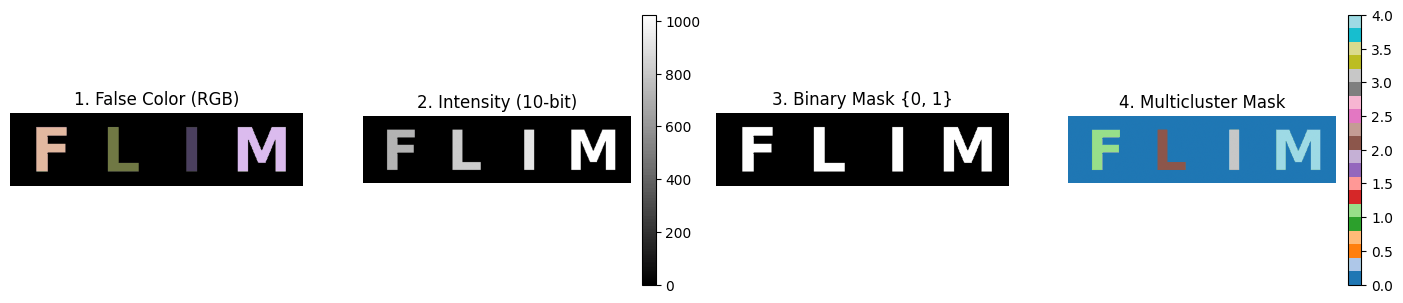

(<Figure size 1400x350 with 6 Axes>,
 array([<Axes: title={'center': '1. False Color (RGB)'}>,
        <Axes: title={'center': '2. Intensity (10-bit)'}>,
        <Axes: title={'center': '3. Binary Mask {0, 1}'}>,
        <Axes: title={'center': '4. Multicluster Mask'}>], dtype=object))

In [2]:
h, w = 128, 512
generator = ROIMaskGenerator((h, w), top=10, bottom=10, left=10, right=10)
FLIM_letters = LettersShape(
    letters=("F", "L", "I", "M"),
    gap=0.15,
)

custom_intensities = [0.7, 0.8, 0.9, 1.0]
# This generates the preview of the generated images
generator.plot_preview(
    FLIM_letters,
    bit_depth=10,
    intensities=custom_intensities,
    show=True,
)

In [ ]:
# Path to the local IRF file (e.g. an SPCImage-exported .txt calibration file)
IRF_PATH = "<select file/folder path>"

In [4]:
loader = DataOperations(irf_path=IRF_PATH)
irf_data = loader.load_irf()

gate_delay = 12.5 / irf_data.shape[2]
num_gates = irf_data.shape[2]
freq = AnalyticalHelpers(
    laser_period=12.5, gate_delay=gate_delay, num_gate=num_gates
).freq_computation()

INFO:pyfli:Initiating IRF load from: <select file/folder path>


In [5]:
# select the type of decay model to simulate
MODEL_TYPE = "mono-exponential"
if MODEL_TYPE == "bi-exponential":
    mono_fraction = 0.0
elif MODEL_TYPE == "mono-exponential":
    mono_fraction = 1.0
else:
    mono_fraction = 0.4  # fraction of mono-exponential model in sampled data


# Your constant, default configuration
BASE_CONFIG = {
    # Modular Noise
    "jitter": False,  # offset artifact (due to jitter)
    "dcr_on": True,  # Dark Count Rate (thermal background)
    "poisson": False,  # Shot noise — Large detector only
    "qe_on": True,  # Quantum efficiency scaling
    "read_noise_on": False,  # Gaussian read noise — Large detector only
    # Sensor
    "sensor_type": "discrete",  # "continuous" | "discrete"
    "bit": 12,
    "dcr": 0.08,  # Mean dark counts per bin
    "laser_feq": freq[1],  # Laser repetition rate (MHz) → period = 12.5 ns
    "round_on": True,  # Round photon counts to integers — Macro_sim only
    "clip_on": True,  # Clip at bit-depth ceiling — Macro_sim: max_adc_val; TCSPC: max_bin_count
    # Fluorescence Physics (FLI / FRET)
    "tau2": (1, 1),  # τ₂ ~ TruncNormal(mu=1 ns, sigma=0.5 ns)
    "tau2_dist": "beta",  # if dist "beta" or "normal" (default)
    "efficiency": (1, 1),  # FRET efficiency E ~ Beta(2, 5)  → [0.1, 1.0]
    "A1_fraction": (1, 1),  # Amplitude fraction A₁ ~ Beta(2, 5) → [0.05, 0.95]
    "photo_count": (2, 5),  # Peak intensity ~ Beta(2, 5) × max_adc - large detectors
    "mono_fraction": mono_fraction,  # Fraction of pixels forced mono-exponential (0.0 = all bi-exp)
    "n_cycles": (1_500_000, 2_000_000),  # Accumulation cycles — for photon counter
}

Different ROIs (letter areas, in this case) are assigned different lifetimes.

In [6]:
def get_config(**kwargs):
    """Create a config by overriding defaults with specific test parameters."""
    config = BASE_CONFIG.copy()
    config.update(kwargs)
    return config


ROI0 = {}
ROI1 = get_config(
    tau2_beta_range=(0.05, 0.5),
)
ROI2 = get_config(
    tau2_beta_range=(0.05, 0.7),
)
ROI3 = get_config(
    tau2_beta_range=(0.05, 0.9),
)
ROI4 = get_config(
    tau2_beta_range=(0.05, 1.1),
)

In [7]:
img_color = generator.generate_color_image(FLIM_letters)
img_intensity = generator.generate_intensity_image(
    FLIM_letters, intensities=custom_intensities
)
img_cluster = generator.generate_cluster_mask(FLIM_letters)
b_bool_mask = generator.generate_binary_mask(FLIM_letters)

simulated_img = FLIModelImageGenerator(
    irf_data=irf_data[120, 40, :],
    intensity_image=img_intensity,
    roi_mask=img_cluster,
    roi_params=[ROI0, ROI1, ROI2, ROI3, ROI4],
    method="PHOTON_COUNTER",
    verbose=True,
    bool_mask=b_bool_mask,
)

gt_data = simulated_img.generate_image()

INFO:pyfli:Generating PHOTON_COUNTER FLI Image [128x512x256]...


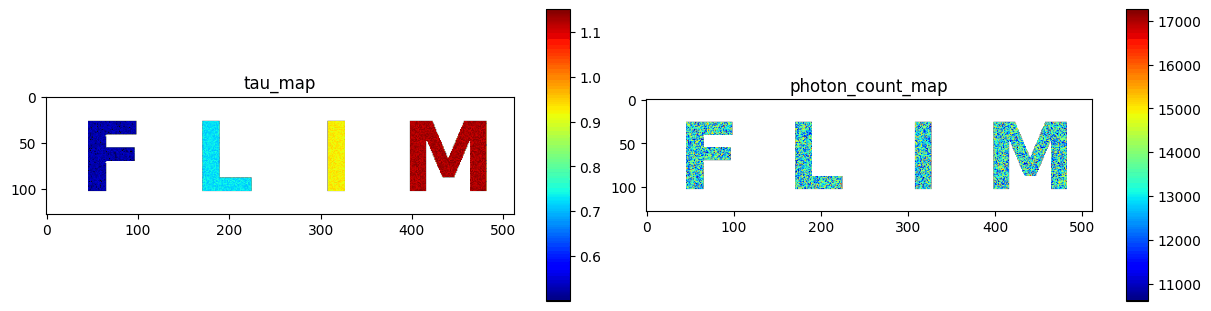

In [8]:
res = gt_data["results"]["maps"]
if MODEL_TYPE == "bi-exponential":
    data_list = [
        res["tau1_map"],
        res["tau2_map"],
        res["alpha1_map"],
        res["A1_map"],
        res["A2_map"],
        res["fret_efficiency_map"],
        res["tau_mean_map"],
        res["photon_count_map"],
    ]
    data_names = [
        "tau1_map",
        "tau2_map",
        "alpha1_map",
        "A1_map",
        "A2_map",
        "fret_efficiency_map",
        "tau_mean_map",
        "photon_count_map",
    ]
    rows = 2
    fig_size = (16, 7)
else:
    data_list = [res["tau_map"], res["photon_count_map"]]
    data_names = ["tau_map", "photon_count_map"]
    rows = 1
    fig_size = (12, 3)
jet_m = ColorProcessor().lowest_zero("jet")
cmaps = [jet_m] * len(data_list)
v_ranges = None
px = None

if px is None:
    cols = int(len(data_list) / rows)
else:
    cols = int(len(data_list) / rows) + 1


_ = DataViewer().display_data(
    data_list,
    structure=(rows, cols),
    coord=px,
    data_names=data_names,
    cmaps=cmaps,
    v_ranges=v_ranges,
    figsize=fig_size,
    normalize=False,
    yscale="linear",
)

the non-zero pixel selected for probing is (62, 78)


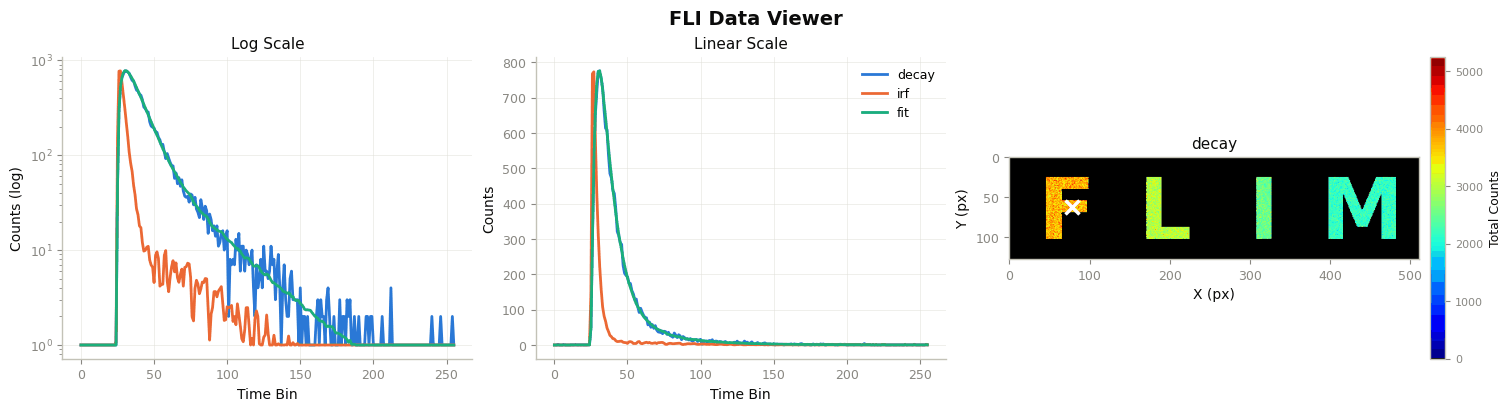

INFO:pyfli:
  Pixel (62, 78)
  ─────────────────────
  A         15104.5098
  α         —
  τ₁        0.5141
  τ₂        —
  R²        —
  Red.χ²    —
  Raw.χ²    —
  v-shift   0.0000
  h-shift   —
  ─────────────────────



In [9]:
sim_decay = gt_data["raw_data"]["decay"]
sim_irf = gt_data["raw_data"]["irf"]
x, y = random_true_pixel(b_bool_mask)
TRs = gt_data["results"]["TR_maps"]
maps = gt_data["results"]["maps"]
print(f"the non-zero pixel selected for probing is ({x}, {y})")
irf_norm = Normalization(sim_irf).norm_scale(sim_decay)
DataViewer().plot_fli_px(
    data_list=[sim_decay, irf_norm, TRs["fit_map"], TRs["residual_map"]],
    pixel=(x, y),
    mode=[0, 1, 2],
    mode2=[1],
    names=["decay", "irf", "fit"],
    cmap=jet_m,
)
_ = MessageDisplay().get_pixel_summary(data_maps=maps, px=(x, y))

#### Factor Analysis

In [10]:
from pyfli.analysis import FactorAnalysis

fa = FactorAnalysis(
    decay=sim_decay,
    irf=sim_irf,
    mask=b_bool_mask,
    all_datasets=[maps],
    all_fitset=[TRs],
    method_names=["ground_truth"],
    cluster_mask=img_cluster,
    cluster_names={1: "F", 2: "L", 3: "I", 4: "M"},
)

Per-pixel photon count (`total_photons`) vs. estimated lifetime, unbinned.

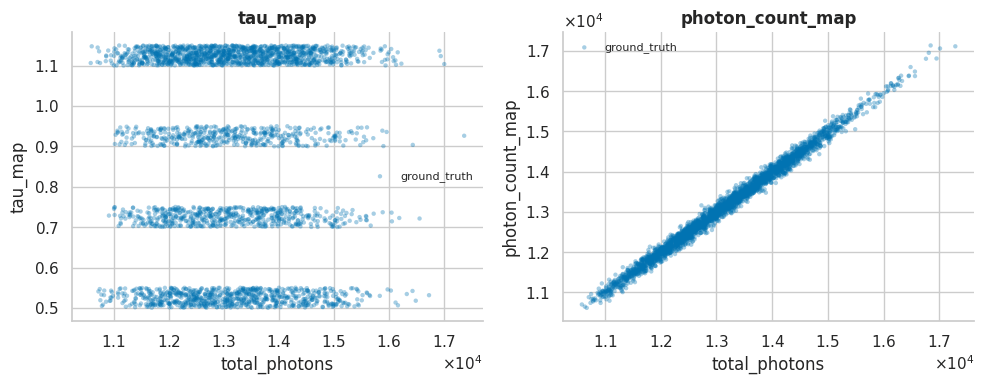

In [11]:
df, edges, fig, axes = fa.analyze_and_plot(
    factor_key="total_photons",
    target_keys=["tau_map", "photon_count_map"],
    kind="scatter",
)

Same pixels grouped into 100 equal-frequency photon-count bins -- mean per bin, with SEM error bands.

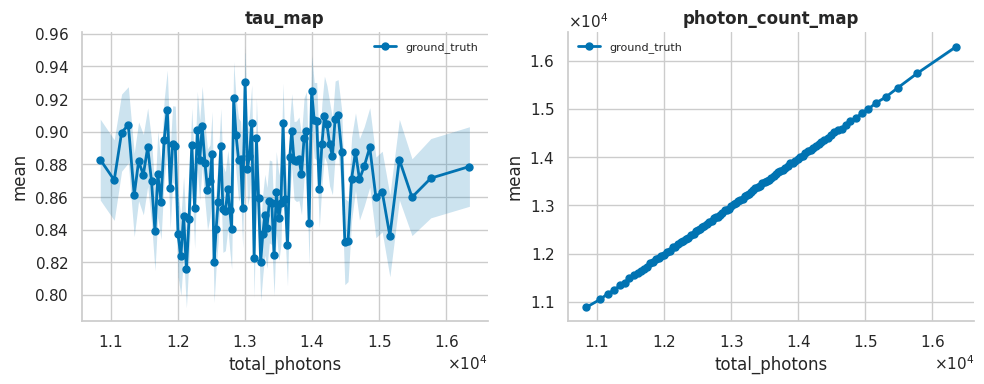

In [12]:
df_binned, edges_binned, fig, axes = fa.analyze_and_plot(
    factor_key="total_photons",
    target_keys=["tau_map", "photon_count_map"],
    n_bins=100,
    bin_mode="quantile",
    kind="line",
    stat="mean",
    error="sem",
)

Coefficient of variation of tau, $\sigma_\tau/\tau$ (per-bin std divided by per-bin mean) -- a scale-free measure of lifetime-estimate precision vs. photon count. Same bins as the plot above.

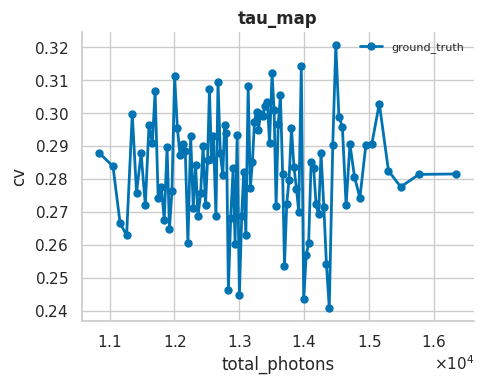

In [13]:
df_cv, edges_cv, fig, axes = fa.analyze_and_plot(
    factor_key="total_photons",
    target_keys=["tau_map"],
    n_bins=100,
    bin_mode="quantile",
    kind="line",
    stat="cv",
    error=None,
)

Full per-bin distribution (not just the mean) of `tau_map`, using fewer bins for readability.

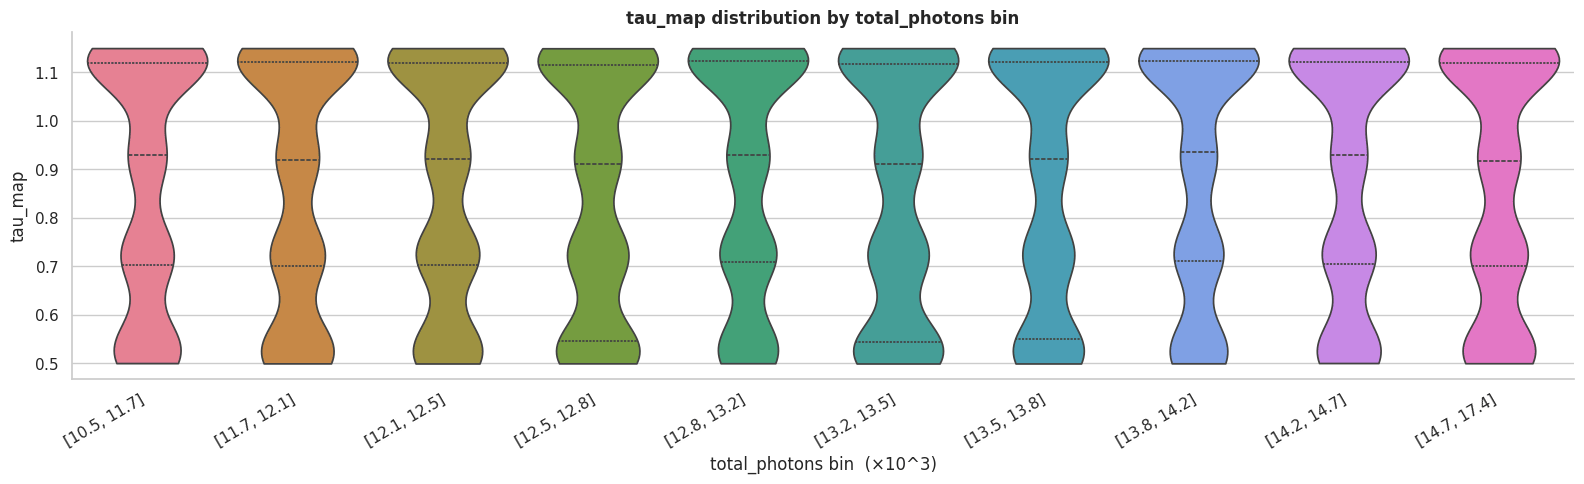

In [14]:
fig, ax, raw_df = fa.plot_bin_distribution(
    "total_photons", "tau_map", n_bins=10
)

Per-pixel peak (max) decay count vs. estimated lifetime.

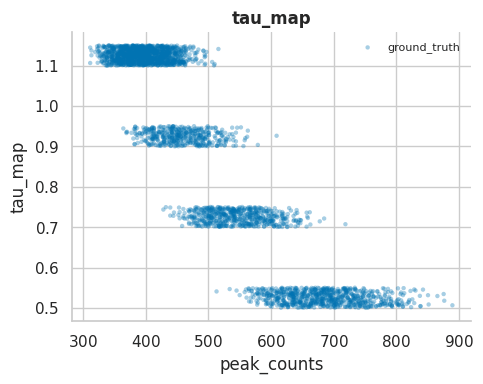

In [15]:
df_peak, edges_peak, fig, axes = fa.analyze_and_plot(
    factor_key="peak_counts",
    target_keys=["tau_map"],
    kind="scatter",
)

#### Cluster-specific analysis

`img_cluster` labels each letter's pixels with a distinct region id (0 = background, 1-4 = F/L/I/M). Passing it as `cluster_mask` lets FactorAnalysis bin/aggregate separately per region, instead of pooling all pixels together -- useful here since each letter was simulated with its own lifetime range.

In [16]:
fa.list_clusters(), fa.cluster_names

([1, 2, 3, 4], {1: 'F', 2: 'L', 3: 'I', 4: 'M'})

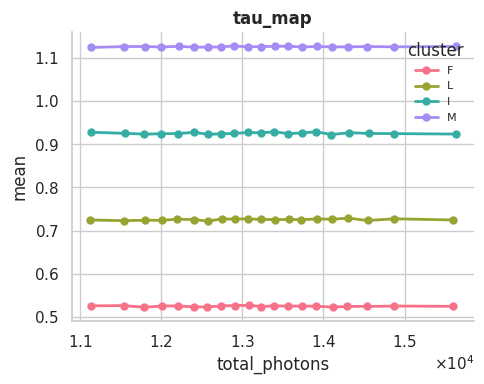

In [17]:
df_cluster, edges_cluster = fa.analyze_by_cluster(
    factor_key="total_photons",
    target_keys=["tau_map"],
    n_bins=20,
)
fig, axes = fa.plot_by_cluster(df_cluster)

Cluster-specific coefficient of variation: $\sigma_\tau/\tau$ per letter (F/L/I/M), reusing `df_cluster` computed above.

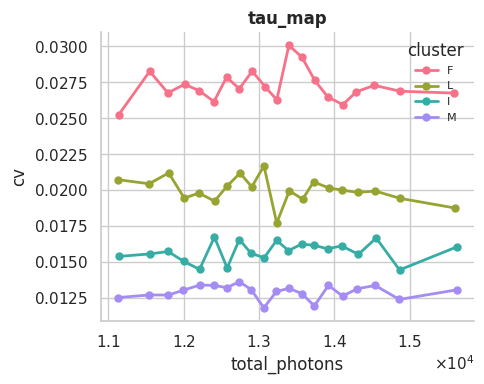

In [18]:
fig, axes = fa.plot_by_cluster(df_cluster, stat="cv", error=None)

## Standalone `CVPlot`

The coefficient-of-variation plots above are all computed through `FactorAnalysis`, which needs the full multi-method comparison setup (`decay`, `irf`, `all_datasets`, `all_fitset`, ...). `pyfli.data_vnp.CVPlot` is a lighter, standalone version of the same `cv = std/mean` binning-by-photon-count logic that works directly on **any** PyFLI fitter's output -- `results["results"]["maps"]` from `FLICPUProcessor` (NLSF or MLE-backed), `FLIGPUProcessor`, or, as here, the simulator's ground-truth `maps` -- since they all share the same map-key convention. No `FactorAnalysis` instance required.

### Binary mask (mono FLIM case, pooled)

Reuses the mono FLIM case's `maps`/`sim_decay`/`b_bool_mask` from the very first example. `photon_map=sim_decay.sum(axis=-1)` bins by the true detected photon count rather than the fitted `photon_count_map` amplitude. The dotted line is the theoretical shot-noise `1/sqrt(N)` trend and the dashed line is a fitted `a*N**b` power law -- see below for why `tau_map` (ground truth) doesn't actually follow either.

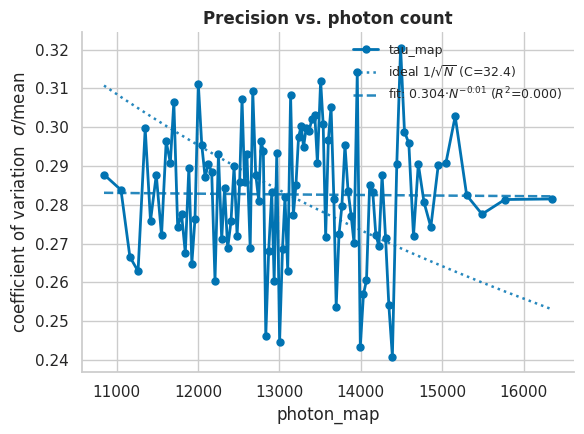

In [19]:
cv_plot = CVPlot()

df_cvplot, fig, axes = cv_plot.compute_and_plot(
    maps,
    tau_keys=["tau_map"],
    photon_map=sim_decay.sum(axis=-1),
    mask=b_bool_mask,
    n_bins=100,
    show_ideal_trend=True,
    show_powerlaw_fit=True,
)

### Multi-cluster mask (mono FLIM case, per letter)

Same `maps`/`sim_decay` as the binary-mask example above, but now with `img_cluster` (F/L/I/M) as `cluster_mask` -- a single subplot (only one parameter, `tau`), one line per letter, again with the ideal and fitted reference curves overlaid.

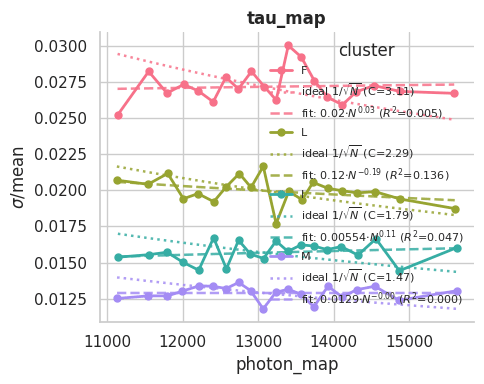

In [20]:
df_cvplot_mono_cluster, fig, axes = cv_plot.compute_and_plot(
    maps,
    tau_keys=["tau_map"],
    photon_map=sim_decay.sum(axis=-1),
    mask=b_bool_mask,
    cluster_mask=img_cluster,
    cluster_names={1: "F", 2: "L", 3: "I", 4: "M"},
    n_bins=20,
    show_ideal_trend=True,
    show_powerlaw_fit=True,
)

### Fitted `tau_map` (mono FLIM case): ground truth vs. NLSF fit

The `tau_map` used above is the simulator's exact ground-truth generating parameter -- written straight from the parameter sampler *before* any decay simulation, noise, or fitting happens. Its per-bin `std` therefore reflects only the deliberately-injected per-letter `tau2_beta_range` heterogeneity (a small, photon-count-*independent* spread), not shot noise -- which is exactly why the CV curves above are flat and the power-law fits land near a slope of 0 with a poor R^2: there's no `1/sqrt(N)` relationship in ground truth to find.

Fitting the noisy `sim_decay` with an actual NLSF solver (`FLICPUProcessor` + `BaseFLIFitter`) instead recovers each pixel's real measurement uncertainty, which *should* follow the shot-noise-limited `1/sqrt(N)` law. Compare the two side by side below.

In [21]:
from pyfli.solver.base_fitter import BaseFLIFitter
from pyfli.solver.cpu_processor import FLICPUProcessor

proc_mono_fit = FLICPUProcessor(freq, BaseFLIFitter)
fit_result_mono = proc_mono_fit.process_image(
    sim_decay,
    sim_irf,
    mask=b_bool_mask,
    model_type="mono-exponential",
)
maps_mono_fitted = fit_result_mono["results"]["maps"]

Fitting Pixels (least_squares): 100%|██████████| 10241/10241 [00:17<00:00, 601.32px/s] 


Binary mask, fitted `tau_map` -- compare this against the "Binary mask (mono FLIM case, pooled)" ground-truth plot above.

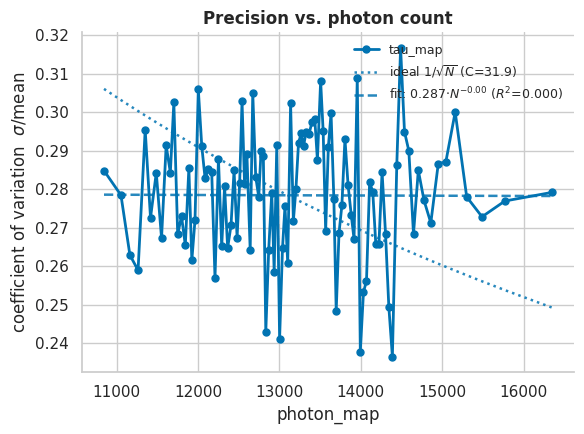

In [22]:
df_cvplot_fitted, fig, axes = cv_plot.compute_and_plot(
    maps_mono_fitted,
    tau_keys=["tau_map"],
    photon_map=sim_decay.sum(axis=-1),
    mask=b_bool_mask,
    n_bins=100,
    show_ideal_trend=True,
    show_powerlaw_fit=True,
)

Multi-cluster mask, fitted `tau_map` -- compare this against the "Multi-cluster mask (mono FLIM case, per letter)" ground-truth plot above (the one that originally prompted this comparison).

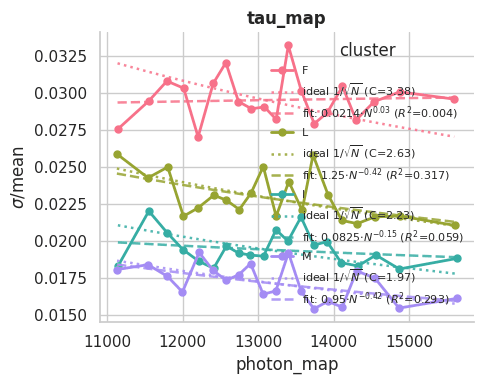

In [23]:
df_cvplot_fitted_cluster, fig, axes = cv_plot.compute_and_plot(
    maps_mono_fitted,
    tau_keys=["tau_map"],
    photon_map=sim_decay.sum(axis=-1),
    mask=b_bool_mask,
    cluster_mask=img_cluster,
    cluster_names={1: "F", 2: "L", 3: "I", 4: "M"},
    n_bins=20,
    show_ideal_trend=True,
    show_powerlaw_fit=True,
)

## Bi-exponential FRET Example

Same simulation setup as above, but with the letters "F", "R", "E", "T" and `MODEL_TYPE = "bi-exponential"`. Everything else (canvas size, IRF, intensities, ROI lifetime ranges) is unchanged.

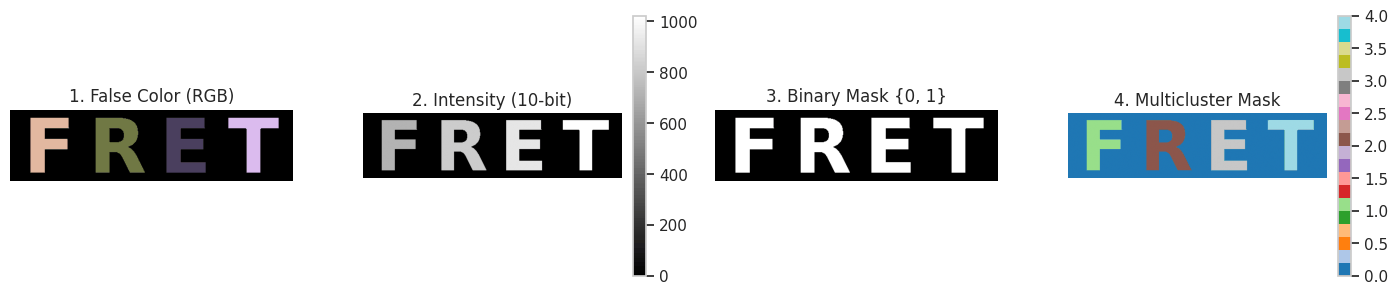

(<Figure size 1400x350 with 6 Axes>,
 array([<Axes: title={'center': '1. False Color (RGB)'}>,
        <Axes: title={'center': '2. Intensity (10-bit)'}>,
        <Axes: title={'center': '3. Binary Mask {0, 1}'}>,
        <Axes: title={'center': '4. Multicluster Mask'}>], dtype=object))

In [24]:
FRET_letters = LettersShape(
    letters=("F", "R", "E", "T"),
    gap=0.15,
)

generator.plot_preview(
    FRET_letters,
    bit_depth=10,
    intensities=custom_intensities,
    show=True,
)

Different ROIs (letter areas, in this case) are assigned different lifetimes.

In [25]:
MODEL_TYPE_fret = "bi-exponential"
mono_fraction_fret = 0.0

BASE_CONFIG_fret = {
    # Modular Noise
    "jitter": False,
    "dcr_on": True,
    "poisson": False,
    "qe_on": True,
    "read_noise_on": False,
    # Sensor
    "sensor_type": "discrete",
    "bit": 12,
    "dcr": 0.08,
    "laser_feq": freq[1],
    "round_on": True,
    "clip_on": True,
    # Fluorescence Physics (FLI / FRET)
    "tau2": (1, 1),
    "tau2_dist": "beta",
    "efficiency": (1, 1),
    "A1_fraction": (1, 1),
    "photo_count": (2, 5),
    "mono_fraction": mono_fraction_fret,
    "n_cycles": (1_500_000, 2_000_000),
}


def get_config_fret(**kwargs):
    """Create a config by overriding defaults with specific test parameters."""
    config = BASE_CONFIG_fret.copy()
    config.update(kwargs)
    return config


ROI0_fret = {}
ROI1_fret = get_config_fret(
    tau2_beta_range=(0.05, 0.5),
)
ROI2_fret = get_config_fret(
    tau2_beta_range=(0.05, 0.7),
)
ROI3_fret = get_config_fret(
    tau2_beta_range=(0.05, 0.9),
)
ROI4_fret = get_config_fret(
    tau2_beta_range=(0.05, 1.1),
)

In [26]:
img_intensity_fret = generator.generate_intensity_image(
    FRET_letters, intensities=custom_intensities
)
img_cluster_fret = generator.generate_cluster_mask(FRET_letters)
b_bool_mask_fret = generator.generate_binary_mask(FRET_letters)

simulated_img_fret = FLIModelImageGenerator(
    irf_data=irf_data[120, 40, :],
    intensity_image=img_intensity_fret,
    roi_mask=img_cluster_fret,
    roi_params=[ROI0_fret, ROI1_fret, ROI2_fret, ROI3_fret, ROI4_fret],
    method="PHOTON_COUNTER",
    verbose=True,
    bool_mask=b_bool_mask_fret,
)

gt_data_fret = simulated_img_fret.generate_image()

INFO:pyfli:Generating PHOTON_COUNTER FLI Image [128x512x256]...


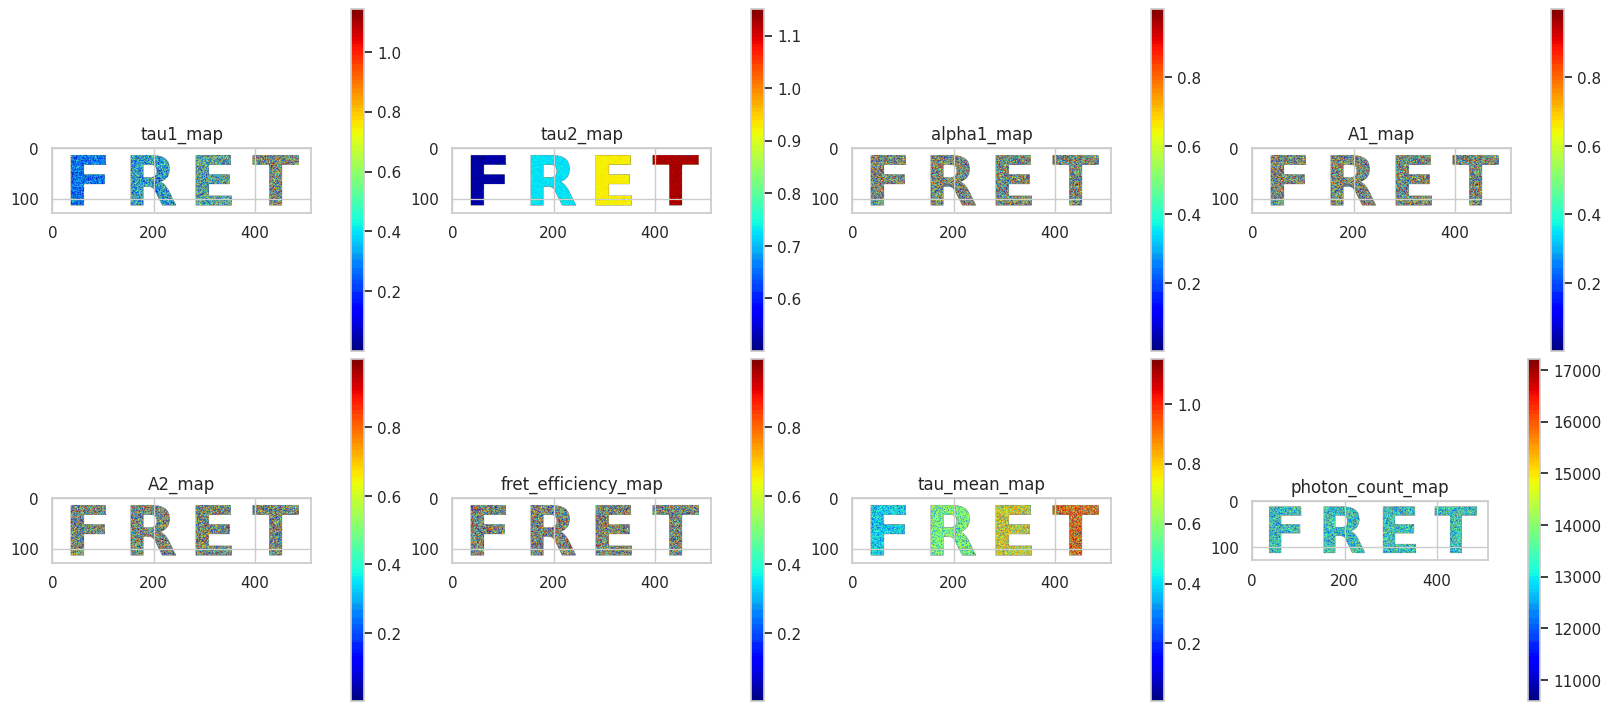

In [27]:
res_fret = gt_data_fret["results"]["maps"]
data_list_fret = [
    res_fret["tau1_map"],
    res_fret["tau2_map"],
    res_fret["alpha1_map"],
    res_fret["A1_map"],
    res_fret["A2_map"],
    res_fret["fret_efficiency_map"],
    res_fret["tau_mean_map"],
    res_fret["photon_count_map"],
]
data_names_fret = [
    "tau1_map",
    "tau2_map",
    "alpha1_map",
    "A1_map",
    "A2_map",
    "fret_efficiency_map",
    "tau_mean_map",
    "photon_count_map",
]

jet_m_fret = ColorProcessor().lowest_zero("jet")
cmaps_fret = [jet_m_fret] * len(data_list_fret)

_ = DataViewer().display_data(
    data_list_fret,
    structure=(2, 4),
    coord=None,
    data_names=data_names_fret,
    cmaps=cmaps_fret,
    v_ranges=None,
    figsize=(16, 7),
    normalize=False,
    yscale="linear",
)

the non-zero pixel selected for probing is (23, 439)


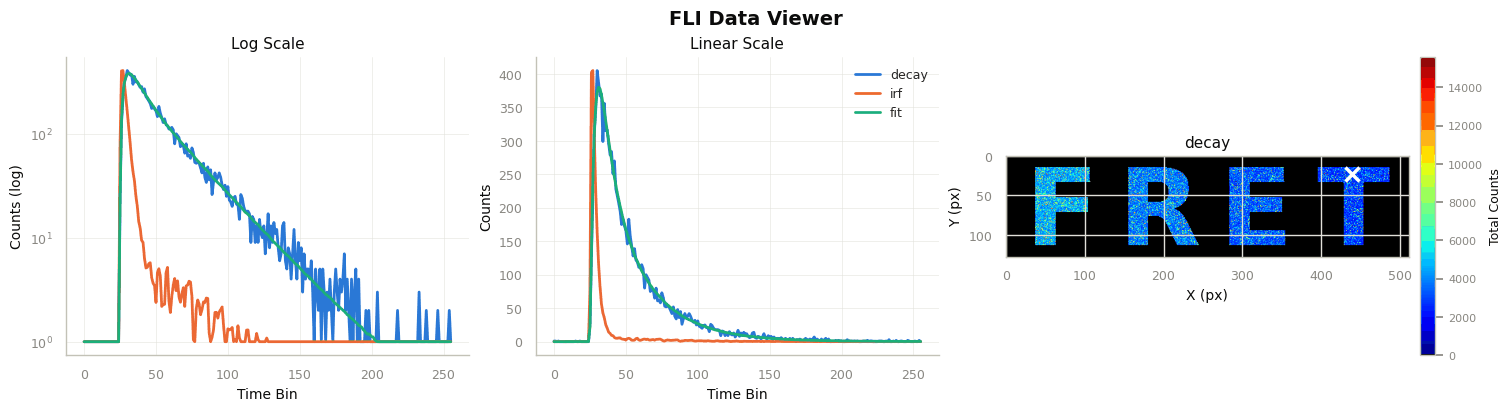

INFO:pyfli:
  Pixel (23, 439)
  ─────────────────────
  A         11268.5508
  α         0.1553
  τ₁        0.3614
  τ₂        1.1407
  R²        —
  Red.χ²    —
  Raw.χ²    —
  v-shift   0.0000
  h-shift   —
  ─────────────────────



In [28]:
sim_decay_fret = gt_data_fret["raw_data"]["decay"]
sim_irf_fret = gt_data_fret["raw_data"]["irf"]
x_fret, y_fret = random_true_pixel(b_bool_mask_fret)
TRs_fret = gt_data_fret["results"]["TR_maps"]
maps_fret = gt_data_fret["results"]["maps"]
print(f"the non-zero pixel selected for probing is ({x_fret}, {y_fret})")
irf_norm_fret = Normalization(sim_irf_fret).norm_scale(sim_decay_fret)
DataViewer().plot_fli_px(
    data_list=[sim_decay_fret, irf_norm_fret, TRs_fret["fit_map"], TRs_fret["residual_map"]],
    pixel=(x_fret, y_fret),
    mode=[0, 1, 2],
    mode2=[1],
    names=["decay", "irf", "fit"],
    cmap=jet_m_fret,
)
_ = MessageDisplay().get_pixel_summary(data_maps=maps_fret, px=(x_fret, y_fret))

#### Factor Analysis (bi-exponential FRET example, more parameter maps)

In [29]:
fa_fret = FactorAnalysis(
    decay=sim_decay_fret,
    irf=sim_irf_fret,
    mask=b_bool_mask_fret,
    all_datasets=[maps_fret],
    all_fitset=[TRs_fret],
    method_names=["ground_truth"],
    cluster_mask=img_cluster_fret,
    cluster_names={1: "F", 2: "R", 3: "E", 4: "T"},
)

target_keys_fret = [
    "tau1_map",
    "tau2_map",
    "alpha1_map",
    "A1_map",
    "A2_map",
    "fret_efficiency_map",
    "tau_mean_map",
    "photon_count_map",
]

Per-pixel photon count vs. every bi-exponential parameter map, unbinned.

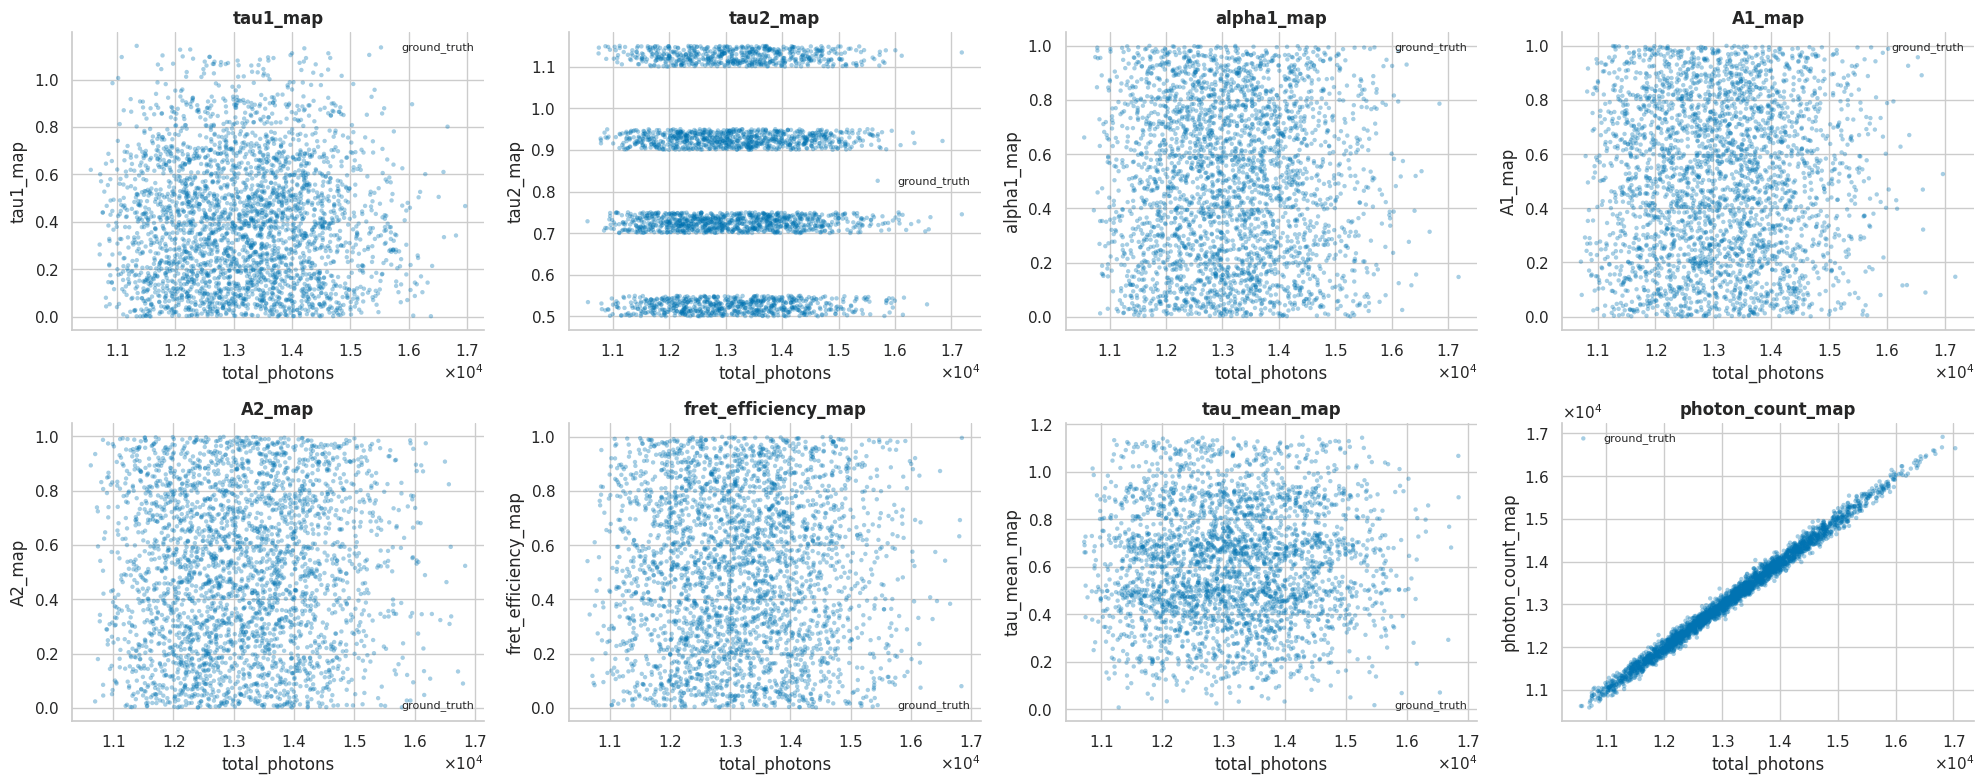

In [30]:
df_fret, edges_fret, fig, axes = fa_fret.analyze_and_plot(
    factor_key="total_photons",
    target_keys=target_keys_fret,
    kind="scatter",
    ncols=4,
)

Same pixels grouped into 100 equal-frequency photon-count bins -- mean per bin, with SEM error bands.

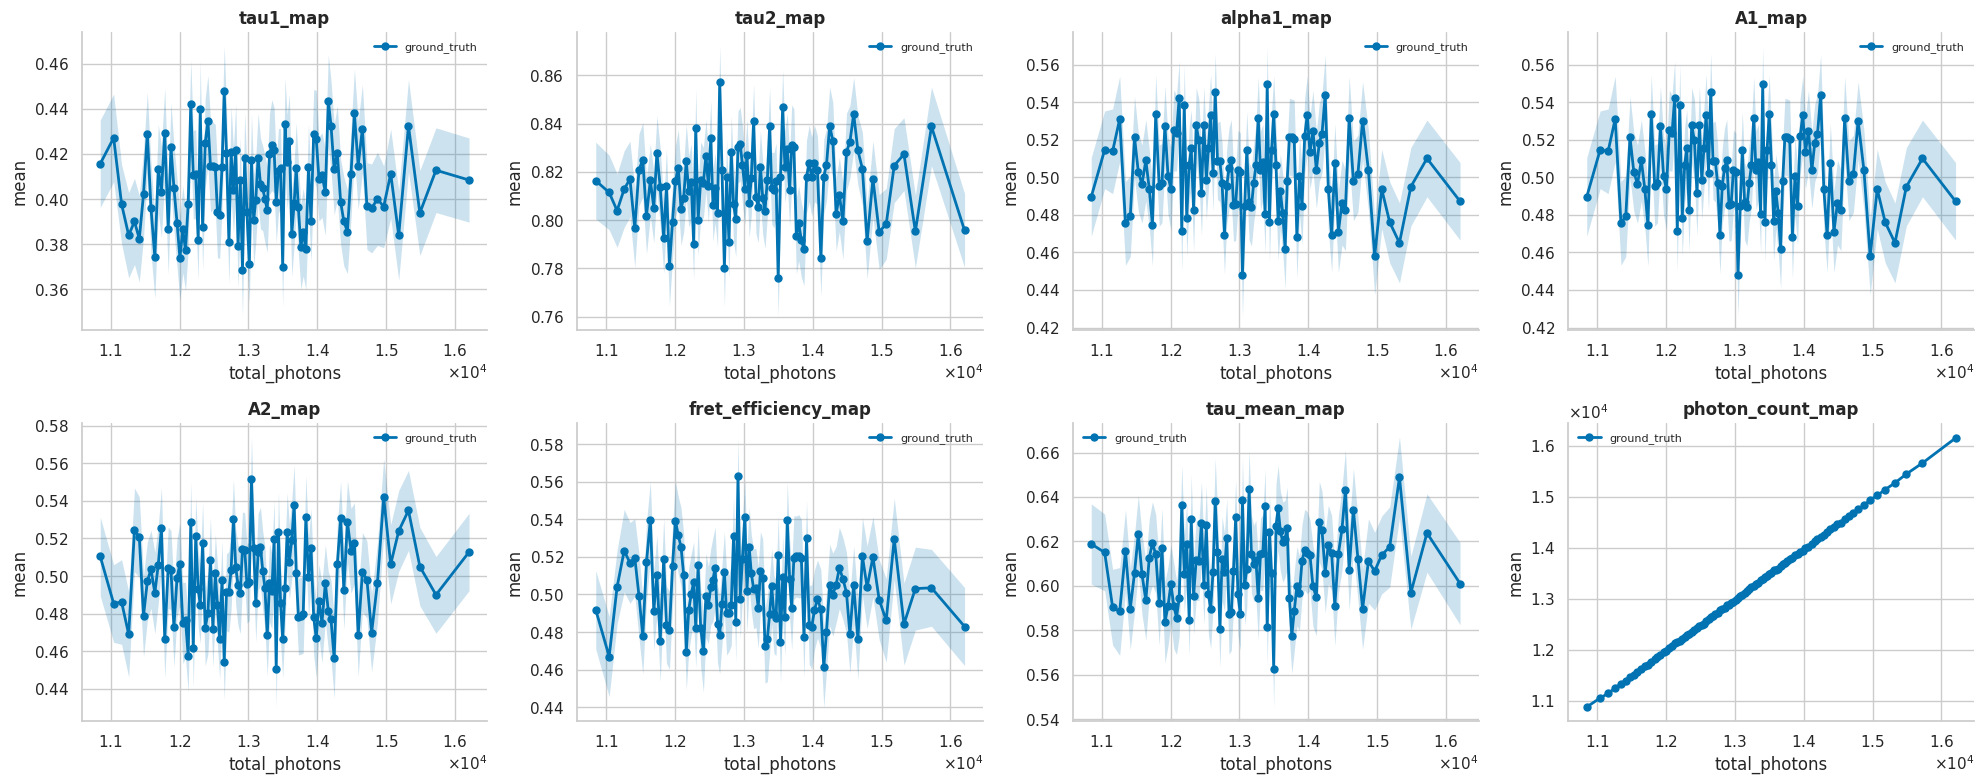

In [31]:
df_fret_binned, edges_fret_binned, fig, axes = fa_fret.analyze_and_plot(
    factor_key="total_photons",
    target_keys=target_keys_fret,
    n_bins=100,
    bin_mode="quantile",
    kind="line",
    stat="mean",
    error="sem",
    ncols=4,
)

Coefficient of variation, $\sigma_\tau/\tau$, for `tau1`, `tau2`, and `tau_mean` vs. photon count.

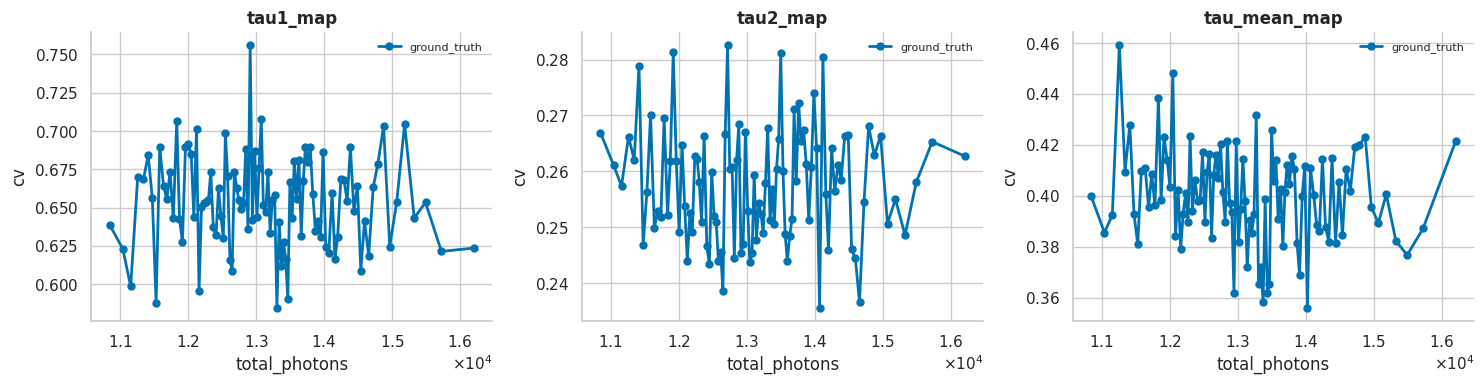

In [32]:
df_fret_cv, edges_fret_cv, fig, axes = fa_fret.analyze_and_plot(
    factor_key="total_photons",
    target_keys=["tau1_map", "tau2_map", "tau_mean_map"],
    n_bins=100,
    bin_mode="quantile",
    kind="line",
    stat="cv",
    error=None,
)

Cluster-specific view: same parameter maps, broken out per letter (F/R/E/T) instead of pooled.

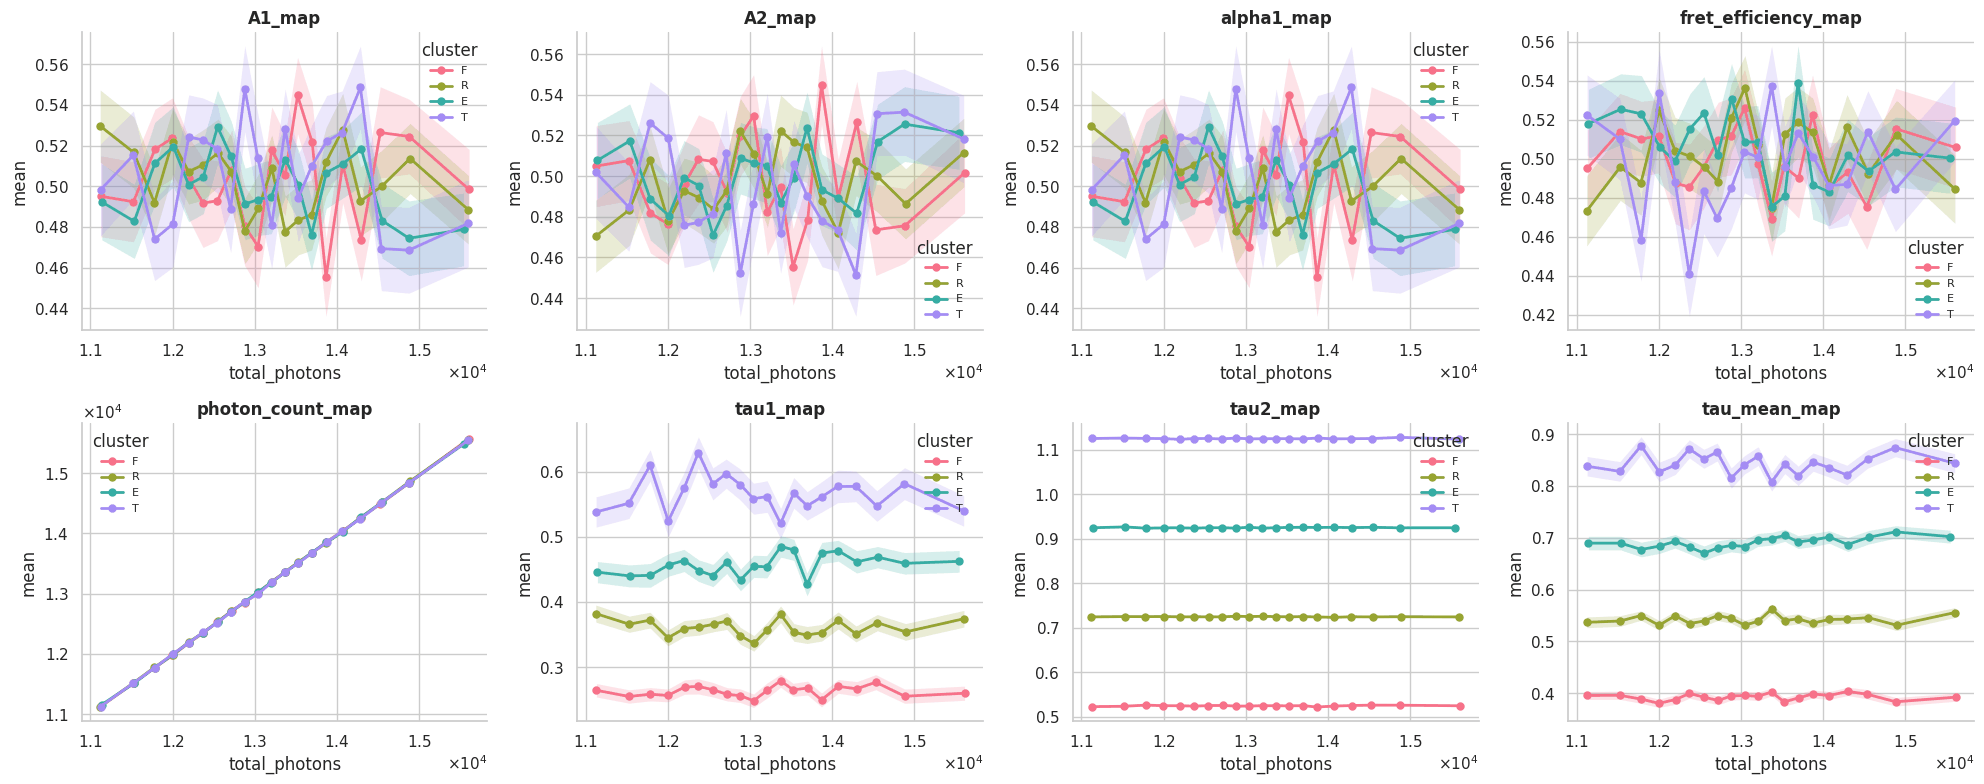

In [33]:
df_fret_cluster, edges_fret_cluster = fa_fret.analyze_by_cluster(
    factor_key="total_photons",
    target_keys=target_keys_fret,
    n_bins=20,
)
fig, axes = fa_fret.plot_by_cluster(df_fret_cluster, ncols=4)

Cluster-specific coefficient of variation: $\sigma_\tau/\tau$ per letter (F/R/E/T), reusing `df_fret_cluster` computed above.

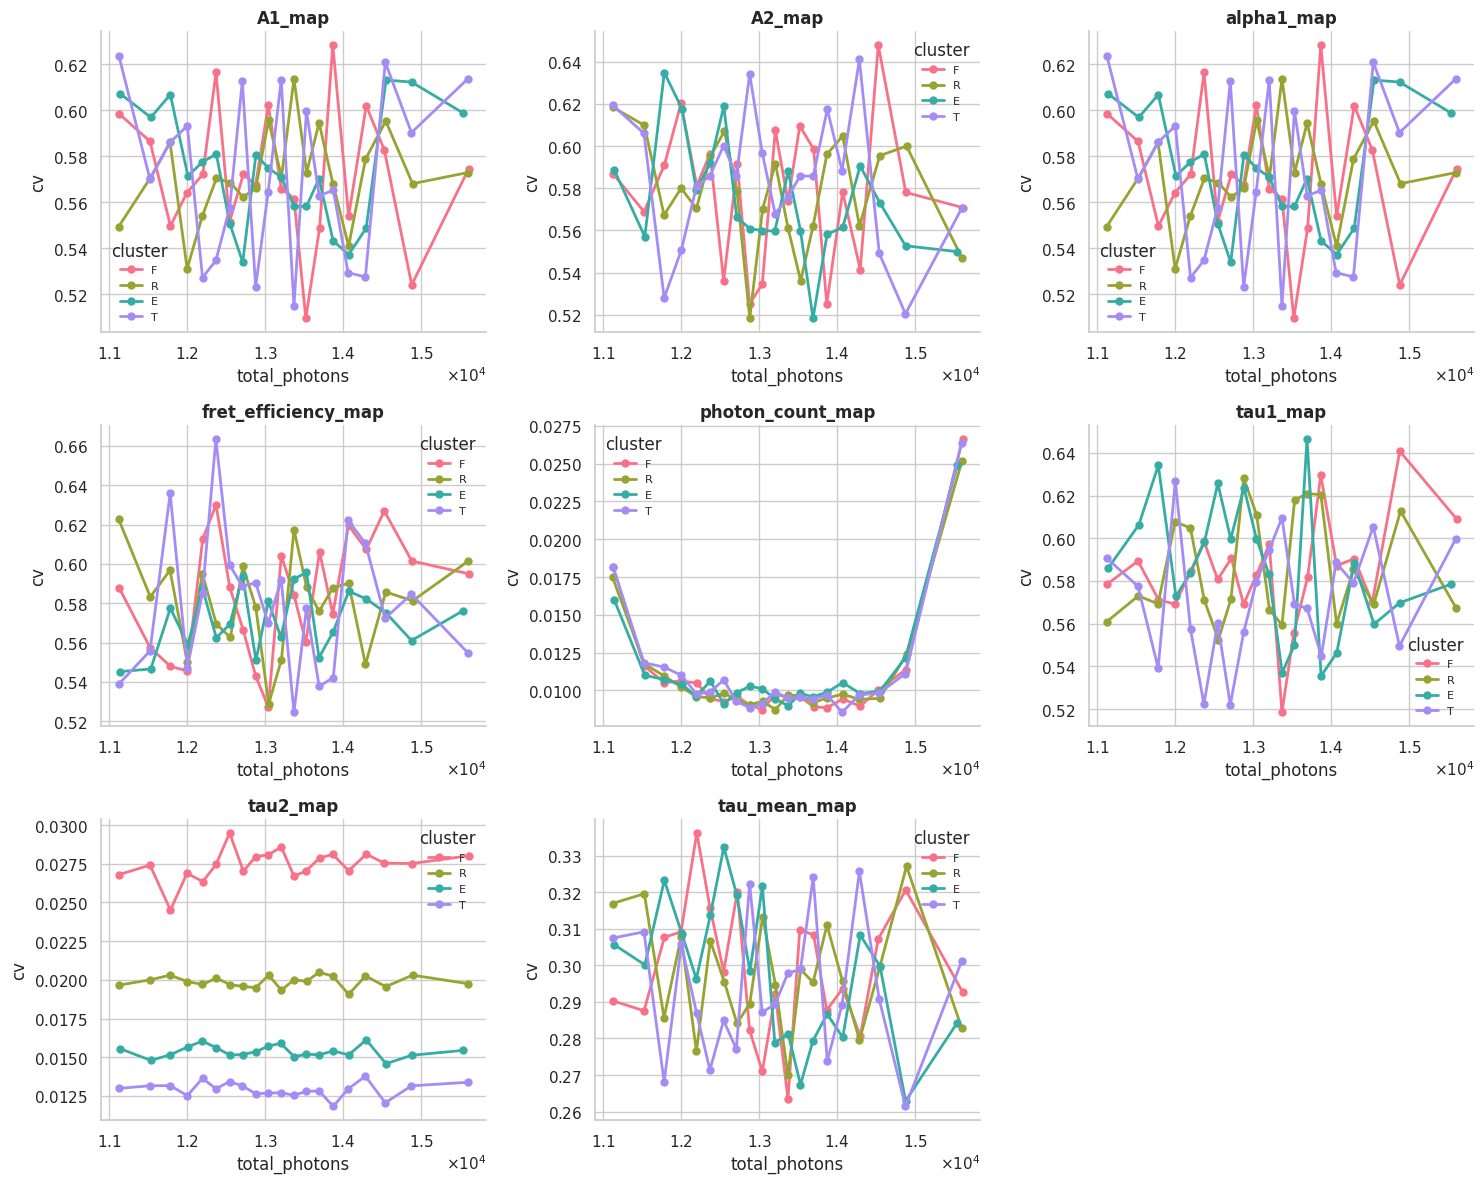

In [34]:
fig, axes = fa_fret.plot_by_cluster(df_fret_cluster, stat="cv", error=None)

## Bi-exponential FLIM Example

Same letters ("F", "L", "I", "M") and the same masks/intensity image as the very first example, but this time with `MODEL_TYPE = "bi-exponential"`. Since `img_intensity`, `img_cluster`, and `b_bool_mask` only depend on the letter shapes (not the decay model), they're reused as-is -- only the ROI photon-physics configs and the simulated decay change.

In [35]:
MODEL_TYPE_flim_bi = "bi-exponential"
mono_fraction_flim_bi = 0.0

BASE_CONFIG_flim_bi = {
    # Modular Noise
    "jitter": False,
    "dcr_on": True,
    "poisson": False,
    "qe_on": True,
    "read_noise_on": False,
    # Sensor
    "sensor_type": "discrete",
    "bit": 12,
    "dcr": 0.08,
    "laser_feq": freq[1],
    "round_on": True,
    "clip_on": True,
    # Fluorescence Physics (FLI / FRET)
    "tau2": (1, 1),
    "tau2_dist": "beta",
    "efficiency": (1, 1),
    "A1_fraction": (1, 1),
    "photo_count": (2, 5),
    "mono_fraction": mono_fraction_flim_bi,
    "n_cycles": (1_500_000, 2_000_000),
}


def get_config_flim_bi(**kwargs):
    """Create a config by overriding defaults with specific test parameters."""
    config = BASE_CONFIG_flim_bi.copy()
    config.update(kwargs)
    return config


ROI0_flim_bi = {}
ROI1_flim_bi = get_config_flim_bi(
    tau2_beta_range=(0.05, 0.5),
)
ROI2_flim_bi = get_config_flim_bi(
    tau2_beta_range=(0.05, 0.7),
)
ROI3_flim_bi = get_config_flim_bi(
    tau2_beta_range=(0.05, 0.9),
)
ROI4_flim_bi = get_config_flim_bi(
    tau2_beta_range=(0.05, 1.1),
)

In [36]:
simulated_img_flim_bi = FLIModelImageGenerator(
    irf_data=irf_data[120, 40, :],
    intensity_image=img_intensity,
    roi_mask=img_cluster,
    roi_params=[ROI0_flim_bi, ROI1_flim_bi, ROI2_flim_bi, ROI3_flim_bi, ROI4_flim_bi],
    method="PHOTON_COUNTER",
    verbose=True,
    bool_mask=b_bool_mask,
)

gt_data_flim_bi = simulated_img_flim_bi.generate_image()

INFO:pyfli:Generating PHOTON_COUNTER FLI Image [128x512x256]...


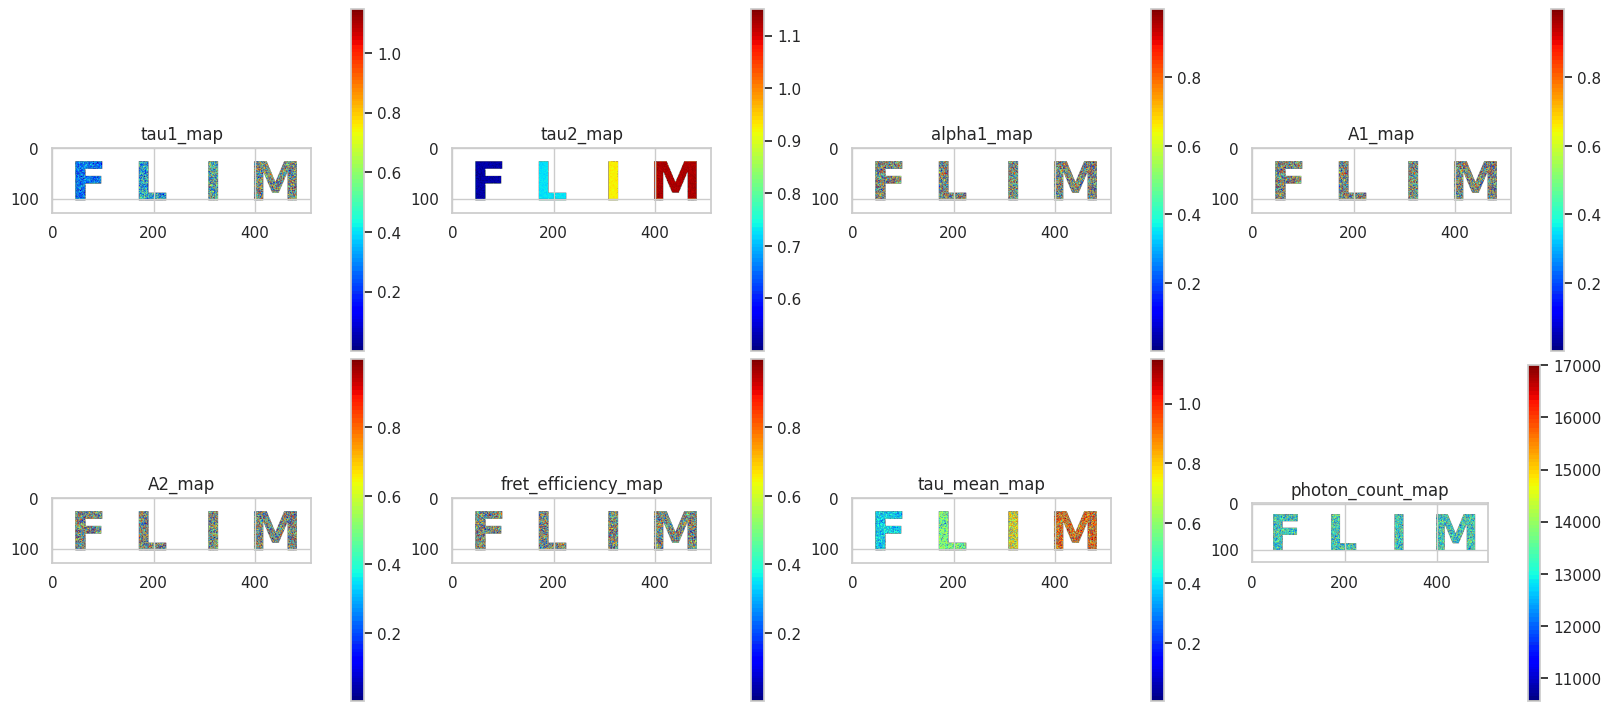

In [37]:
res_flim_bi = gt_data_flim_bi["results"]["maps"]
data_list_flim_bi = [
    res_flim_bi["tau1_map"],
    res_flim_bi["tau2_map"],
    res_flim_bi["alpha1_map"],
    res_flim_bi["A1_map"],
    res_flim_bi["A2_map"],
    res_flim_bi["fret_efficiency_map"],
    res_flim_bi["tau_mean_map"],
    res_flim_bi["photon_count_map"],
]
data_names_flim_bi = [
    "tau1_map",
    "tau2_map",
    "alpha1_map",
    "A1_map",
    "A2_map",
    "fret_efficiency_map",
    "tau_mean_map",
    "photon_count_map",
]

jet_m_flim_bi = ColorProcessor().lowest_zero("jet")
cmaps_flim_bi = [jet_m_flim_bi] * len(data_list_flim_bi)

_ = DataViewer().display_data(
    data_list_flim_bi,
    structure=(2, 4),
    coord=None,
    data_names=data_names_flim_bi,
    cmaps=cmaps_flim_bi,
    v_ranges=None,
    figsize=(16, 7),
    normalize=False,
    yscale="linear",
)

the non-zero pixel selected for probing is (92, 216)


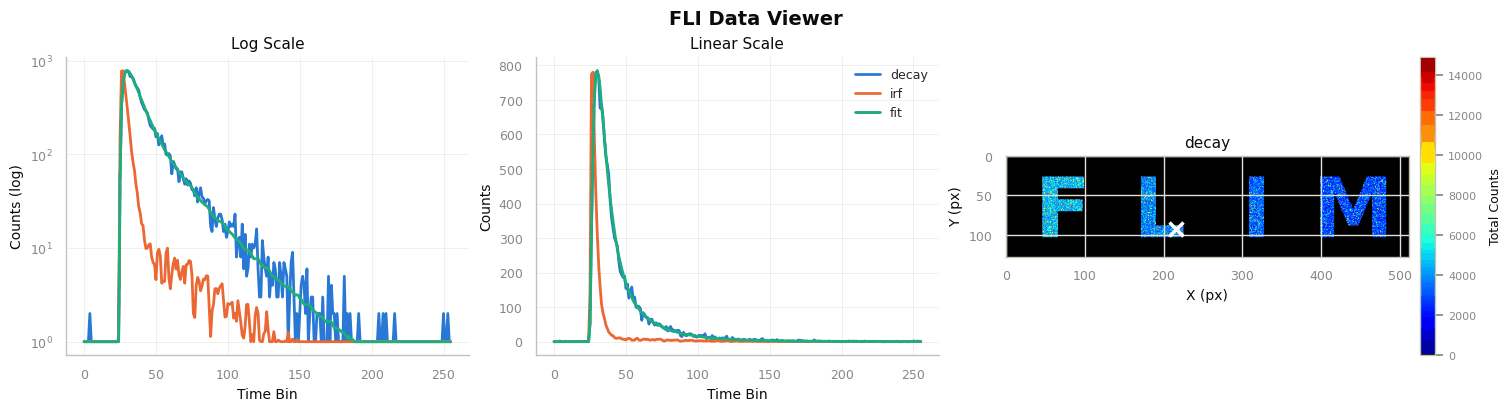

INFO:pyfli:
  Pixel (92, 216)
  ─────────────────────
  A         14563.5049
  α         0.3559
  τ₁        0.2625
  τ₂        0.7167
  R²        —
  Red.χ²    —
  Raw.χ²    —
  v-shift   0.0000
  h-shift   —
  ─────────────────────



In [38]:
sim_decay_flim_bi = gt_data_flim_bi["raw_data"]["decay"]
sim_irf_flim_bi = gt_data_flim_bi["raw_data"]["irf"]
x_flim_bi, y_flim_bi = random_true_pixel(b_bool_mask)
TRs_flim_bi = gt_data_flim_bi["results"]["TR_maps"]
maps_flim_bi = gt_data_flim_bi["results"]["maps"]
print(f"the non-zero pixel selected for probing is ({x_flim_bi}, {y_flim_bi})")
irf_norm_flim_bi = Normalization(sim_irf_flim_bi).norm_scale(sim_decay_flim_bi)
DataViewer().plot_fli_px(
    data_list=[sim_decay_flim_bi, irf_norm_flim_bi, TRs_flim_bi["fit_map"], TRs_flim_bi["residual_map"]],
    pixel=(x_flim_bi, y_flim_bi),
    mode=[0, 1, 2],
    mode2=[1],
    names=["decay", "irf", "fit"],
    cmap=jet_m_flim_bi,
)
_ = MessageDisplay().get_pixel_summary(data_maps=maps_flim_bi, px=(x_flim_bi, y_flim_bi))

#### Factor Analysis (bi-exponential FLIM example, more parameter maps)

In [39]:
fa_flim_bi = FactorAnalysis(
    decay=sim_decay_flim_bi,
    irf=sim_irf_flim_bi,
    mask=b_bool_mask,
    all_datasets=[maps_flim_bi],
    all_fitset=[TRs_flim_bi],
    method_names=["ground_truth"],
    cluster_mask=img_cluster,
    cluster_names={1: "F", 2: "L", 3: "I", 4: "M"},
)

target_keys_flim_bi = target_keys_fret

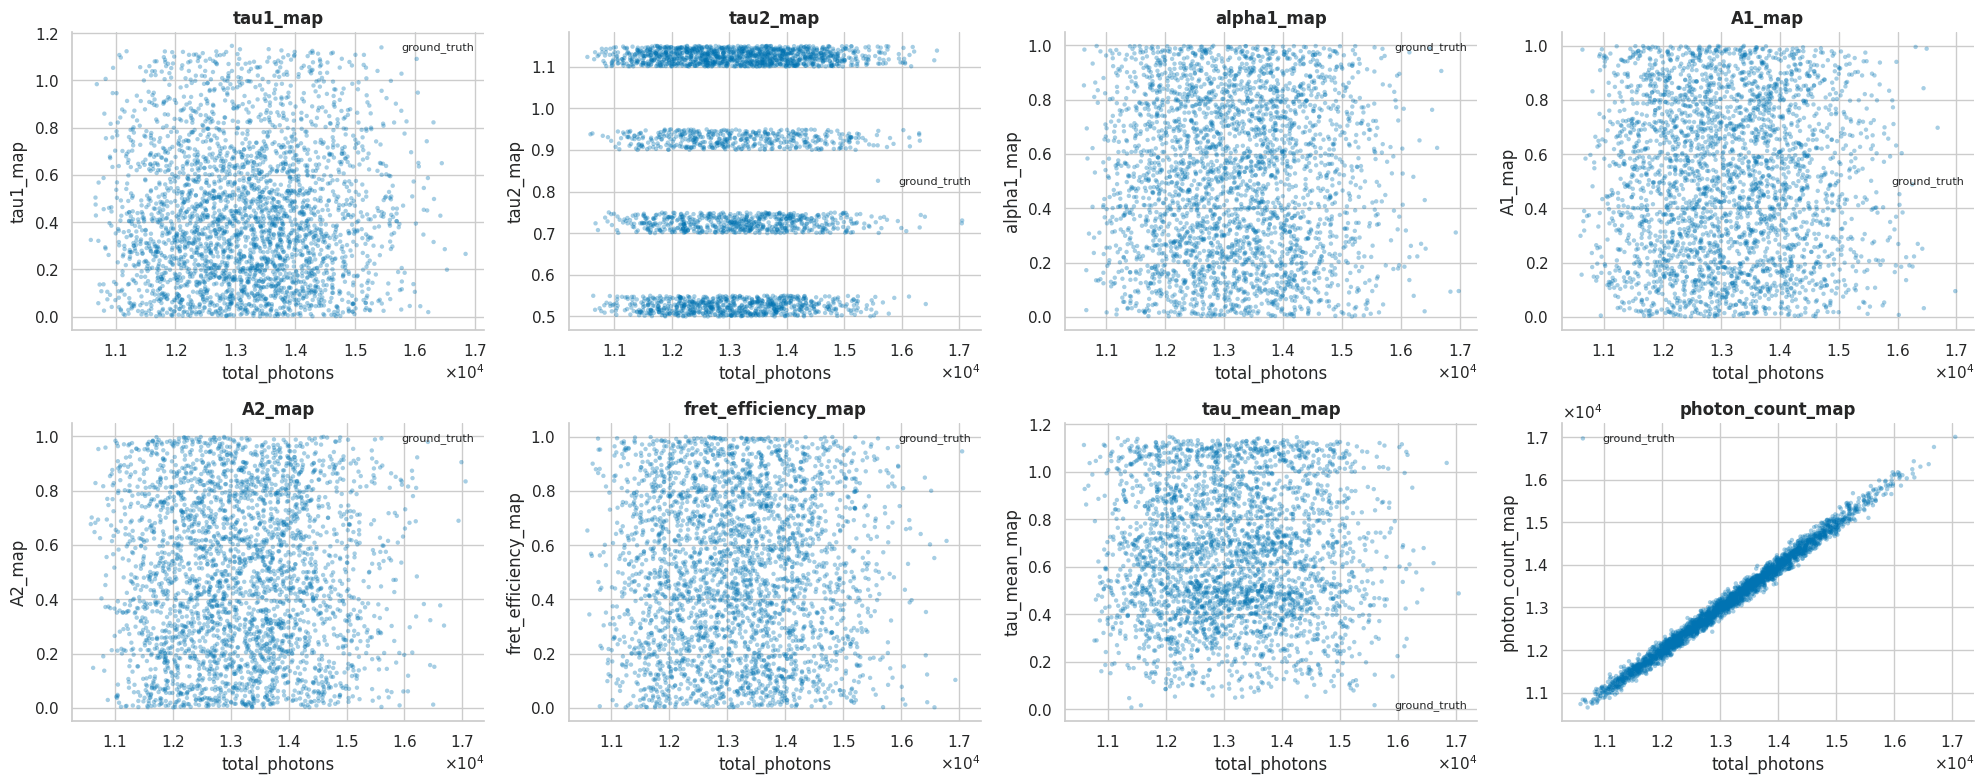

In [40]:
df_flim_bi, edges_flim_bi, fig, axes = fa_flim_bi.analyze_and_plot(
    factor_key="total_photons",
    target_keys=target_keys_flim_bi,
    kind="scatter",
    ncols=4,
)

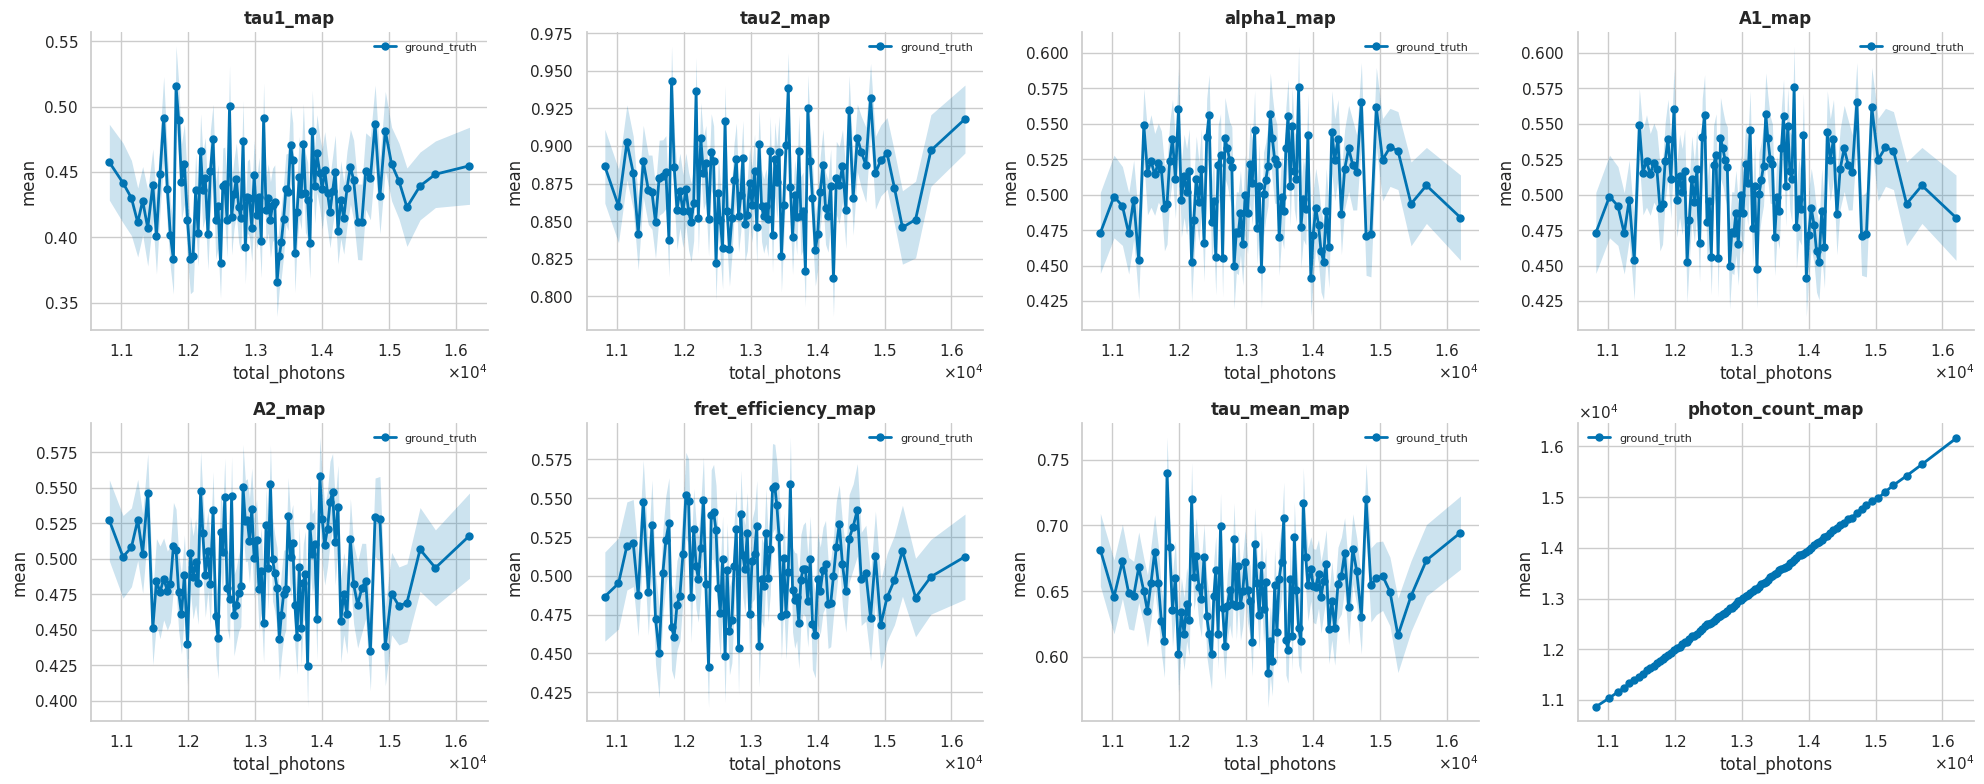

In [41]:
df_flim_bi_binned, edges_flim_bi_binned, fig, axes = fa_flim_bi.analyze_and_plot(
    factor_key="total_photons",
    target_keys=target_keys_flim_bi,
    n_bins=100,
    bin_mode="quantile",
    kind="line",
    stat="mean",
    error="sem",
    ncols=4,
)

Coefficient of variation, $\sigma_\tau/\tau$, for `tau1`, `tau2`, and `tau_mean` vs. photon count.

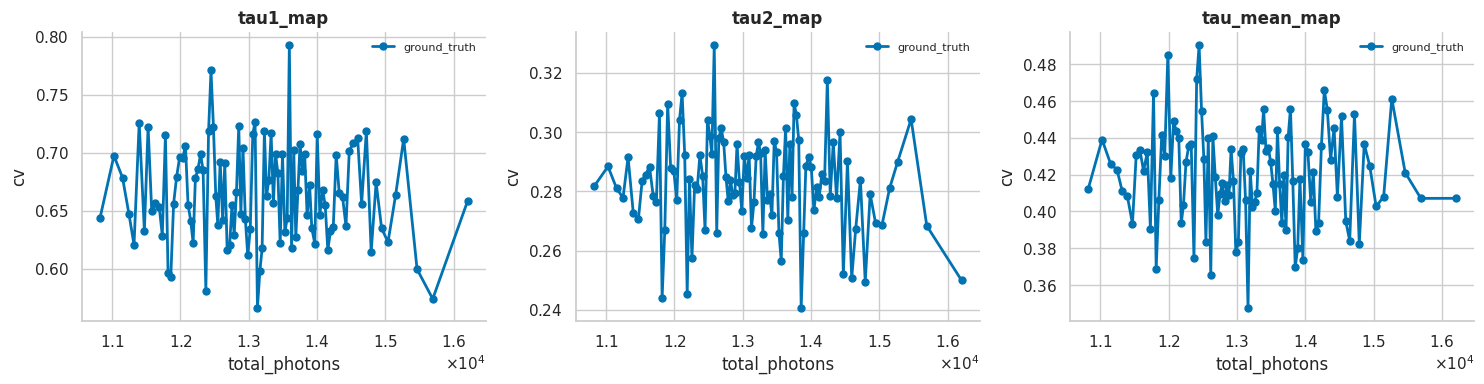

In [42]:
df_flim_bi_cv, edges_flim_bi_cv, fig, axes = fa_flim_bi.analyze_and_plot(
    factor_key="total_photons",
    target_keys=["tau1_map", "tau2_map", "tau_mean_map"],
    n_bins=100,
    bin_mode="quantile",
    kind="line",
    stat="cv",
    error=None,
)

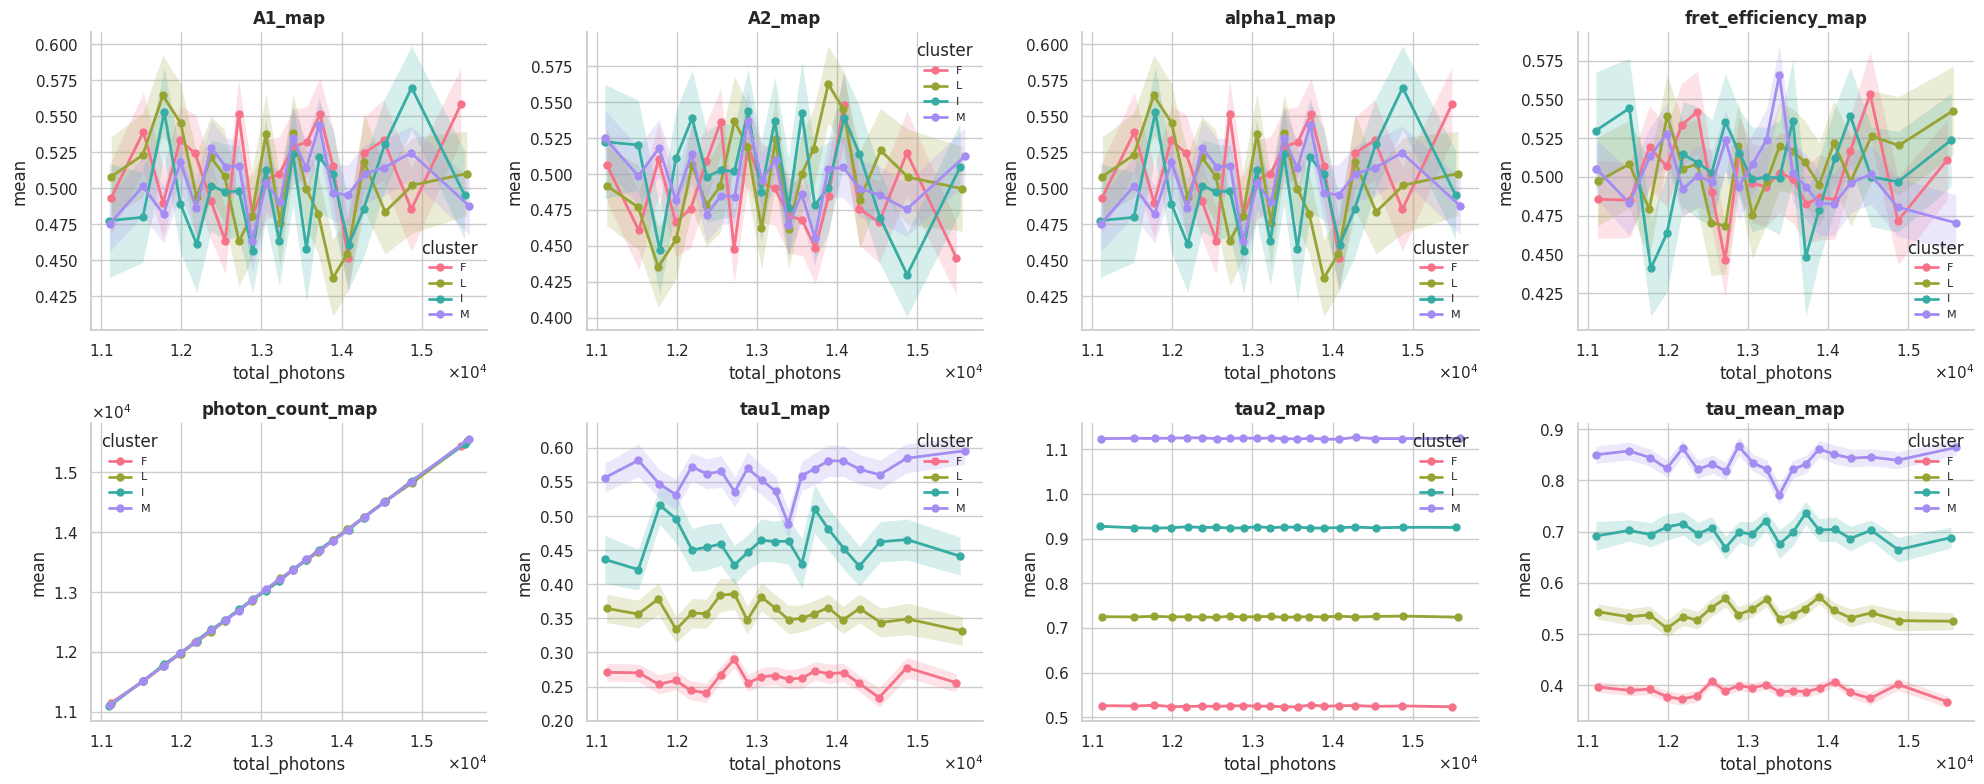

In [43]:
df_flim_bi_cluster, edges_flim_bi_cluster = fa_flim_bi.analyze_by_cluster(
    factor_key="total_photons",
    target_keys=target_keys_flim_bi,
    n_bins=20,
)
fig, axes = fa_flim_bi.plot_by_cluster(df_flim_bi_cluster, ncols=4)

Cluster-specific coefficient of variation: $\sigma_\tau/\tau$ per letter (F/L/I/M), reusing `df_flim_bi_cluster` computed above.

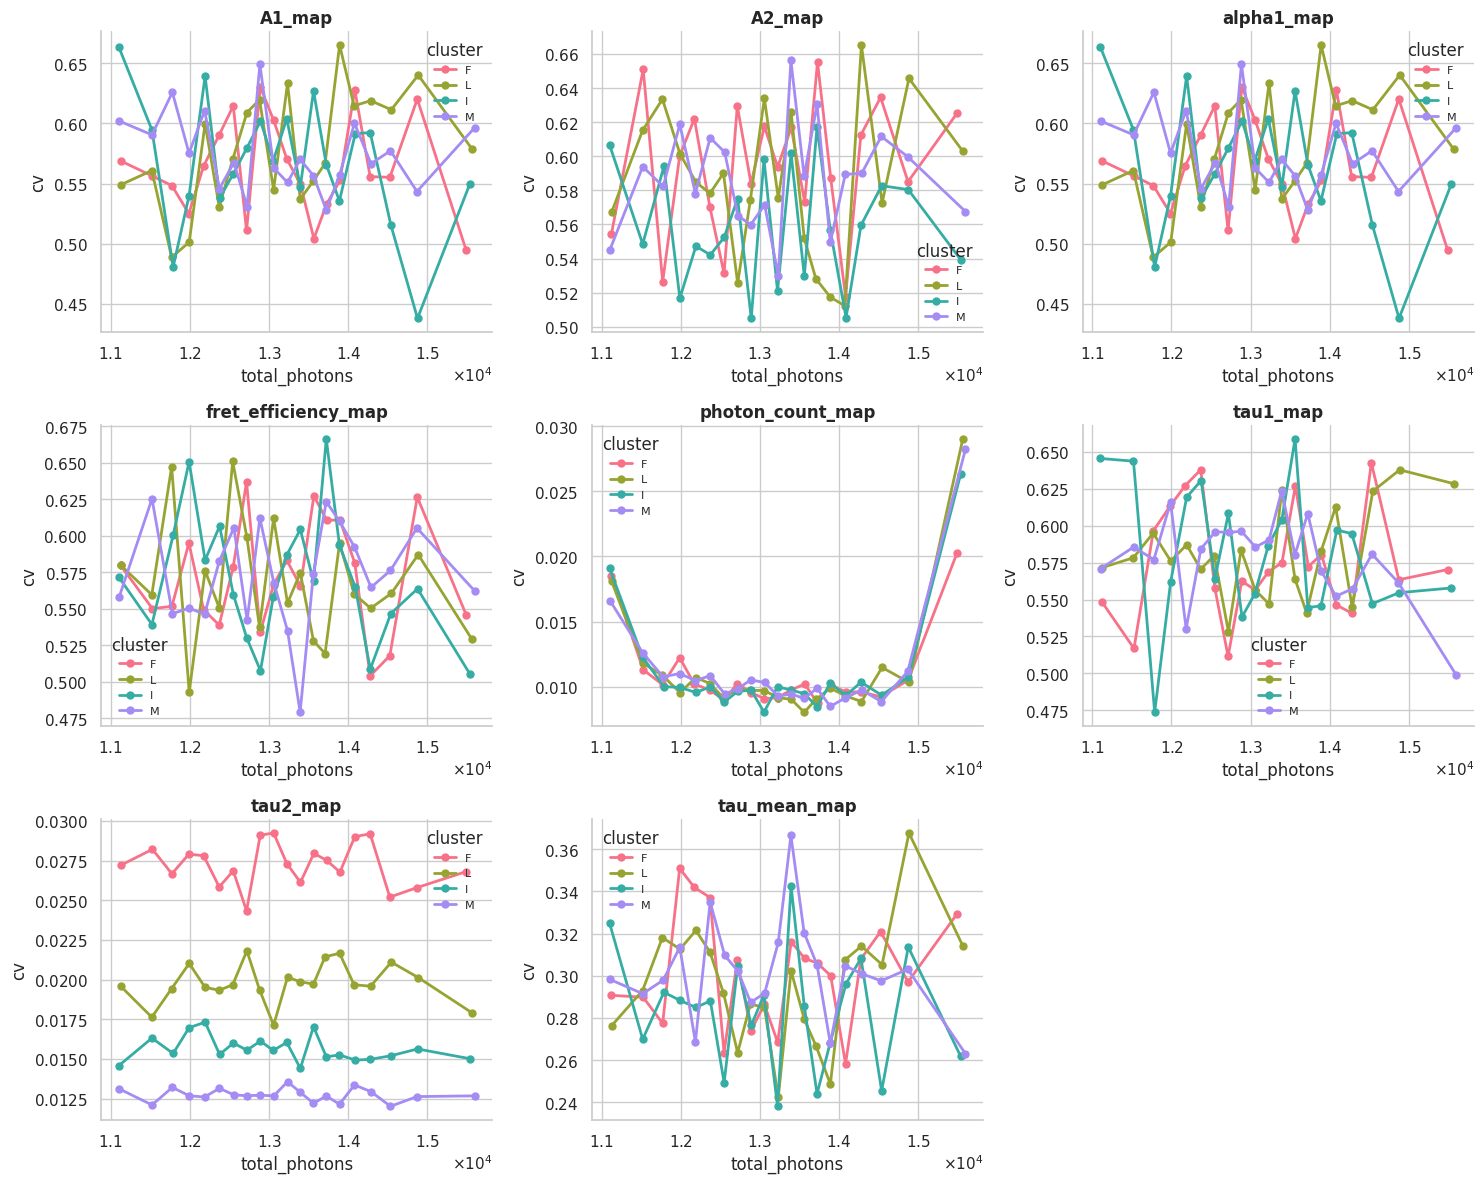

In [44]:
fig, axes = fa_flim_bi.plot_by_cluster(df_flim_bi_cluster, stat="cv", error=None)

### Standalone `CVPlot`: multi-cluster mask (bi-exponential FLIM case, per letter)

Same lightweight `pyfli.data_vnp.CVPlot` class used for the mono FLIM case earlier in this notebook, now applied to `maps_flim_bi`/`sim_decay_flim_bi` with `img_cluster` (F/L/I/M) as `cluster_mask` -- one subplot per parameter (`tau1`, `tau2`, `tau_mean`), one line per letter.

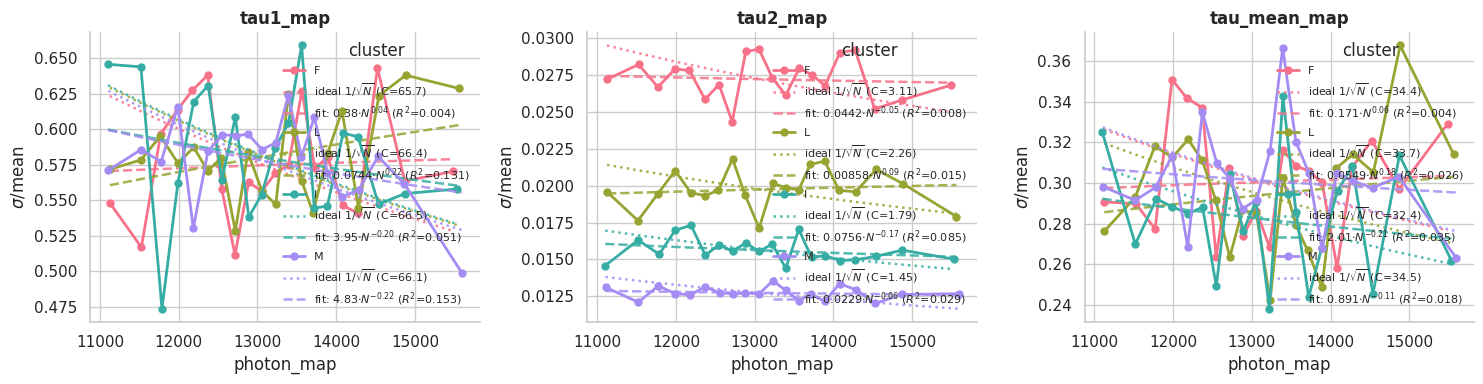

In [45]:
df_cvplot_cluster, fig, axes = cv_plot.compute_and_plot(
    maps_flim_bi,
    tau_keys=["tau1_map", "tau2_map", "tau_mean_map"],
    photon_map=sim_decay_flim_bi.sum(axis=-1),
    mask=b_bool_mask,
    cluster_mask=img_cluster,
    cluster_names={1: "F", 2: "L", 3: "I", 4: "M"},
    n_bins=20,
    show_ideal_trend=True,
    show_powerlaw_fit=True,
)

## Comparing FLIM vs FRET (bi-exponential)

Both simulations share the same parameter map names (bi-exponential model), but come from independent decay cubes with different masks -- so `FactorAnalysis.compare()` is used instead of `plot()`/`plot_by_cluster()`, which assume one shared decay across series. Each dataset's line is drawn at its own actual `total_photons` bin means.

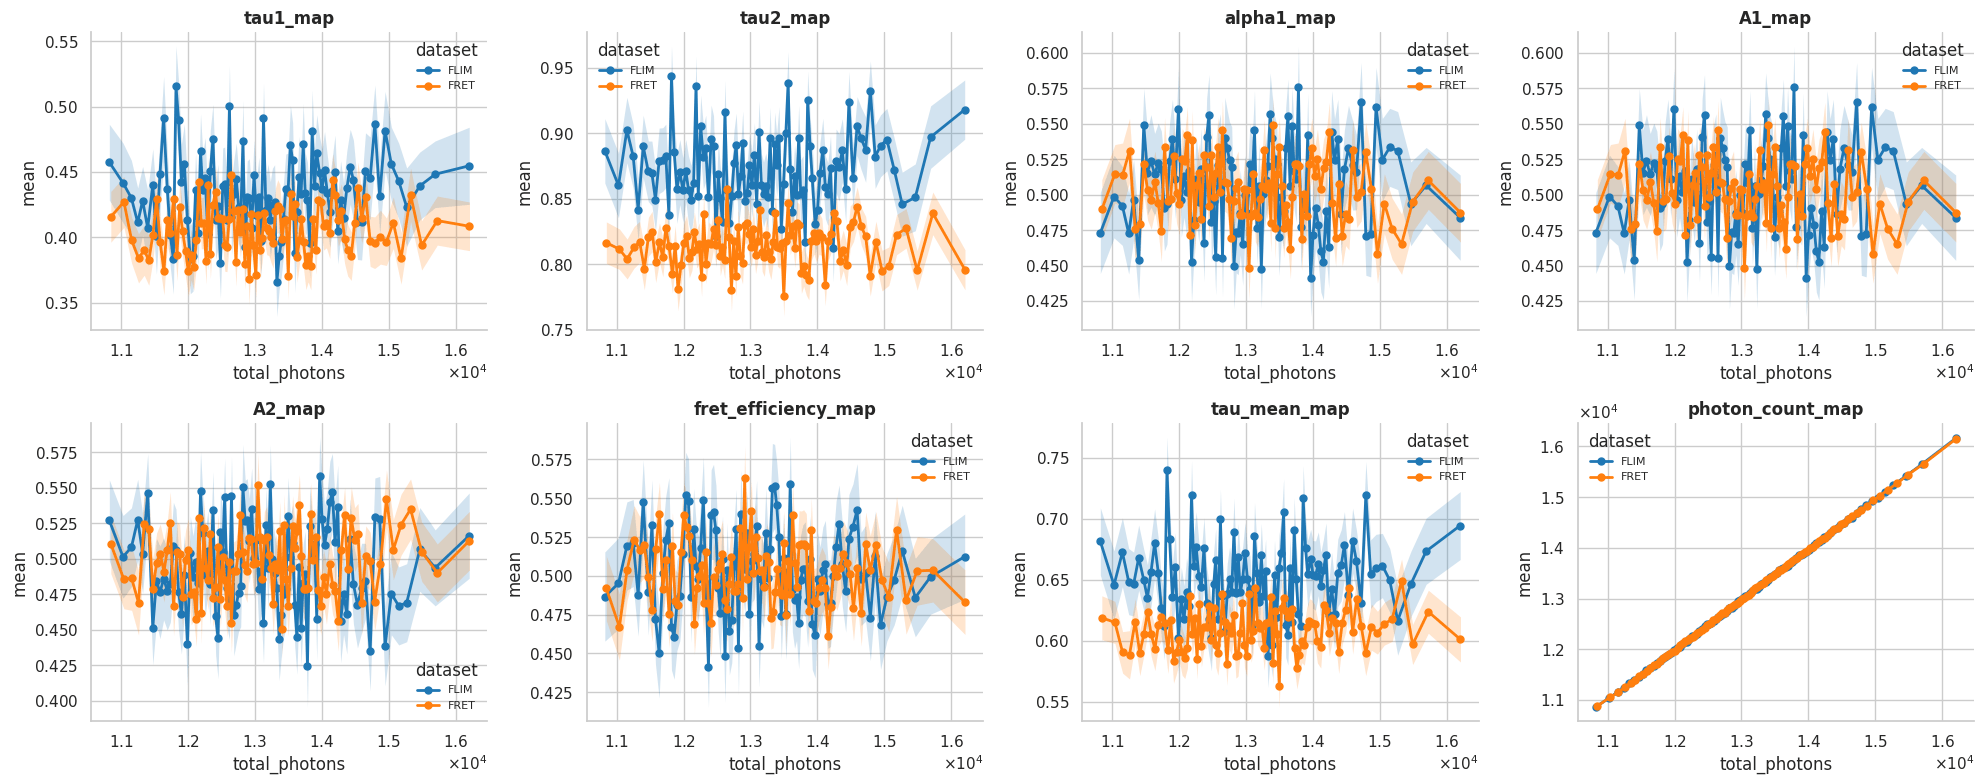

In [46]:
fig, axes = FactorAnalysis.compare(
    [("FLIM", df_flim_bi_binned), ("FRET", df_fret_binned)],
    target_keys=target_keys_fret,
    ncols=4,
)